# Prediction Stability Under Resampling in WDBC

## Objective

Before model development, verify the provenance, structure, outcome coding, and predictor definitions of the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.

This stage is intentionally performed before model fitting or outcome-driven exploration.

The objectives are to establish:
1. the exact analysis dataset;
2. the observational unit;
3. the meaning and structure of the predictors;
4. the positive-outcome convention;
5. the absence or presence of missing values and exact duplicate predictor rows;
6. reproducible structural checks that future runs of the analysis must satisfy.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import sklearn

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y_original = data.target.copy()
y = (y_original == 0).astype(int)
y.name = "malignant"

## Dataset representation

The analysis uses the WDBC dataset distributed through `sklearn.datasets.load_breast_cancer`.

The dataset contains:
- 569 observations;
- 30 quantitative predictors derived from nuclear morphology;
- 212 malignant observations;
- 357 benign observations.

The scikit-learn representation encodes:
- `0 = malignant`
- `1 = benign`

For this project, the outcome is explicitly recoded as:
- `1 = malignant`
- `0 = benign`

This convention ensures that predicted probabilities consistently refer to the probability of malignancy.

All subsequent model evaluation will use this explicitly recoded outcome rather than relying on the original class ordering.

## Structural audit

The initial structural audit confirmed:
- predictor matrix shape: `569 × 30`;
- all predictors are numeric (`float64`);
- no missing predictor values;
- no missing outcome values;
- no exact duplicate rows across the 30 predictors;
- all expected malignant and benign observations are present;
- no predictor is constant.

The absence of exact duplicate predictor rows does not establish statistical independence of the observations. It only confirms that no two rows contain identical values across all 30 predictors.

In [2]:
feature_audit = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing": X.isna().sum().values,
    "n_unique": X.nunique().values,
    "min": X.min().values,
    "max": X.max().values,
})
feature_audit

,feature,dtype,missing,n_unique,min,max
0,mean radius,float64,0,456,6.981000,28.11000
1,mean texture,float64,0,479,9.710000,39.28000
2,mean perimeter,float64,0,522,43.790000,188.50000
3,mean area,float64,0,539,143.500000,2501.00000
4,mean smoothness,float64,0,474,0.052630,0.16340
5,mean compactness,float64,0,537,0.019380,0.34540
6,mean concavity,float64,0,537,0.000000,0.42680
7,mean concave points,float64,0,542,0.000000,0.20120
8,mean symmetry,float64,0,432,0.106000,0.30400
9,mean fractal dimension,float64,0,499,0.049960,0.09744


## Predictor provenance and structure

The 30 predictors are constructed from ten underlying nuclear-morphology characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

Each characteristic is represented using three summaries: `mean`, `standard error`, and `worst`.

$$
10 \text{ morphological characteristics} \times 3 \text{ summaries} = 30 \text{ predictors}.
$$

### Structural validation result

All 30 predictor names matched the expected WDBC feature structure.

## Implications for the analysis

The WDBC predictors contain known structural relationships. Predictor dependence is expected from the feature-construction process itself.

All 30 predictors will remain part of the prespecified analysis dataset.

##
Decisions frozen after Stage 1A–1B

- use the scikit-learn representation of WDBC;
- retain all 569 observations;
- retain all 30 quantitative predictors;
- explicitly encode malignant as `1`;
- perform no imputation or feature selection during dataset preparation.

## Analyses deliberately not performed at this stage

No model fitting, train/test splitting, feature selection, PCA, or hyperparameter optimization was performed during the dataset audit.

## Observation identifiers

The scikit-learn representation used in this project does not expose the
original UCI case identifier as an analysis variable.

Stable internal identifiers (`WDBC_000` to `WDBC_568`) were therefore created
solely for tracking observations across resampling repetitions and generated
result tables.

These identifiers are analytical row identifiers and must not be interpreted
as original patient identifiers.

In [3]:
# 1. Create stable internal IDs
observation_id = pd.Series(
    [f"WDBC_{i:03d}" for i in range(len(X))],
    name="observation_id"
)

print(observation_id.head())

0    WDBC_000
1    WDBC_001
2    WDBC_002
3    WDBC_003
4    WDBC_004
Name: observation_id, dtype: str


In [4]:
# 2. Construct master analysis table
analysis_df = X.copy()

analysis_df.insert(0, "observation_id", observation_id.values)
analysis_df["malignant"] = y.values

print("Analysis table shape:", analysis_df.shape)
print("Unique observation IDs:", analysis_df["observation_id"].nunique())
print("Number malignant:", analysis_df["malignant"].sum())

Analysis table shape: (569, 32)
Unique observation IDs: 569
Number malignant: 212


In [5]:
# 3. Frozen column schema definitions
FEATURE_COLUMNS = tuple(X.columns)
TARGET_COLUMN = "malignant"
ID_COLUMN = "observation_id"

print("Number of feature columns:", len(FEATURE_COLUMNS))
print("Target:", TARGET_COLUMN)
print("ID:", ID_COLUMN)

# Construct the frozen analysis matrices
X_analysis = analysis_df.loc[:, FEATURE_COLUMNS].copy()
y_analysis = analysis_df[TARGET_COLUMN].copy()
ids_analysis = analysis_df[ID_COLUMN].copy()

Number of feature columns: 30
Target: malignant
ID: observation_id


## Analysis data contract

All subsequent analyses must operate on the same frozen representation:

- observational unit: one WDBC breast-mass case;
- number of observations: 569;
- predictors: the 30 predefined quantitative WDBC morphology variables;
- predictor order: preserved exactly as distributed by scikit-learn;
- outcome: binary diagnosis recoded as `malignant = 1`, `benign = 0`;
- observation identifier: project-specific internal ID, excluded from modeling;
- missing-value handling: none required;
- feature selection during data preparation: none.

The model input is therefore:

$$X \in \mathbb{R}^{569 \times 30}$$

and:

$$y \in \{0,1\}^{569},$$

where `1` denotes malignancy.

Observation identifiers and the outcome column are never included in the predictor matrix.

In [6]:
# 5. Automated integrity checks
assert analysis_df.shape == (569, 32)

assert analysis_df[ID_COLUMN].is_unique
assert analysis_df[ID_COLUMN].notna().all()

assert len(FEATURE_COLUMNS) == 30
assert len(set(FEATURE_COLUMNS)) == 30

assert list(X_analysis.columns) == list(FEATURE_COLUMNS)
assert X_analysis.shape == (569, 30)

assert X_analysis.isna().sum().sum() == 0

assert set(y_analysis.unique()) == {0, 1}
assert y_analysis.sum() == 212
assert (y_analysis == 0).sum() == 357

assert ID_COLUMN not in FEATURE_COLUMNS
assert TARGET_COLUMN not in FEATURE_COLUMNS

assert X_analysis.index.equals(y_analysis.index)
assert X_analysis.index.equals(ids_analysis.index)

print("Analysis data contract checks passed.")

Analysis data contract checks passed.


In [7]:
import hashlib
import numpy as np

def compute_dataset_fingerprint(X, y, feature_names):
    hasher = hashlib.sha256()

    # Feature names
    schema = "\n".join(feature_names).encode("utf-8")
    hasher.update(schema)

    # Numeric predictor values encoded as little-endian float64 bytes
    X_bytes = np.asarray(X, dtype="<f8", order="C").tobytes(order="C")
    hasher.update(X_bytes)

    # Outcome values encoded as bytes
    y_bytes = np.asarray(y, dtype=np.uint8).tobytes(order="C")
    hasher.update(y_bytes)

    return hasher.hexdigest()

dataset_sha256 = compute_dataset_fingerprint(
    X_analysis,
    y_analysis,
    FEATURE_COLUMNS
)

print("Analysis dataset SHA-256:")
print(dataset_sha256)

Analysis dataset SHA-256:
be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61


In [8]:
import sys
import sklearn

software_provenance = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
}

dataset_provenance = {
    "dataset": "Wisconsin Diagnostic Breast Cancer (WDBC)",
    "analysis_source": "sklearn.datasets.load_breast_cancer",
    "n_observations": len(X_analysis),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "positive_outcome": "malignant",
    "analysis_sha256": dataset_sha256,
}

print("Software provenance:", software_provenance)
print("\nDataset provenance:", dataset_provenance)

Software provenance: {'python': '3.13.12', 'numpy': '2.4.4', 'pandas': '3.0.2', 'scikit_learn': '1.8.0'}

Dataset provenance: {'dataset': 'Wisconsin Diagnostic Breast Cancer (WDBC)', 'analysis_source': 'sklearn.datasets.load_breast_cancer', 'n_observations': 569, 'n_predictors': 30, 'n_malignant': 212, 'n_benign': 357, 'positive_outcome': 'malignant', 'analysis_sha256': 'be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61'}


In [9]:
# Validate strict observation-ID ordering
assert ids_analysis.iloc[0] == "WDBC_000"
assert ids_analysis.iloc[-1] == "WDBC_568"
assert ids_analysis.tolist() == [f"WDBC_{i:03d}" for i in range(569)]

print("Observation ordering is stable.\n")

# Final data-integrity summary
data_contract_summary = pd.Series({
    "n_observations": len(analysis_df),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "missing_predictor_values": int(X_analysis.isna().sum().sum()),
    "duplicate_predictor_rows": int(X_analysis.duplicated().sum()),
    "unique_observation_ids": int(ids_analysis.nunique()),
    "dataset_sha256": dataset_sha256,
})

print(data_contract_summary)

Observation ordering is stable.

n_observations                                                            569
n_predictors                                                               30
n_malignant                                                               212
n_benign                                                                  357
missing_predictor_values                                                    0
duplicate_predictor_rows                                                    0
unique_observation_ids                                                    569
dataset_sha256              be06e11b816f830afa615fe2296762d77eb9e29429b057...
dtype: object


## Figure 1: Experimental design and stability framework

Figure 1 summarizes the repeated redevelopment design used to distinguish 
aggregate predictive-performance stability from observation-level prediction stability.

The WDBC dataset was evaluated using 50 repetitions of stratified 5-fold 
cross-validation. Within each repetition, every observation was held out exactly once, 
producing one out-of-sample (OOS) predicted probability per observation. Repeating this 
procedure yielded 50 OOS probabilities for each observation and learning procedure.

Stability was then evaluated at two complementary levels:

1. **Aggregate performance stability:** ROC-AUC and Brier score were calculated for 
   each redevelopment repetition.

2. **Individual prediction stability:** for each observation, redevelopment sensitivity 
   was summarized as the central 80% prediction width,

   \[
   W_i = P_{90}(p_i) - P_{10}(p_i).
   \]

The repeated cross-validation runs represent alternative redevelopment samples from the 
same dataset and are not interpreted as independent patient cohorts.

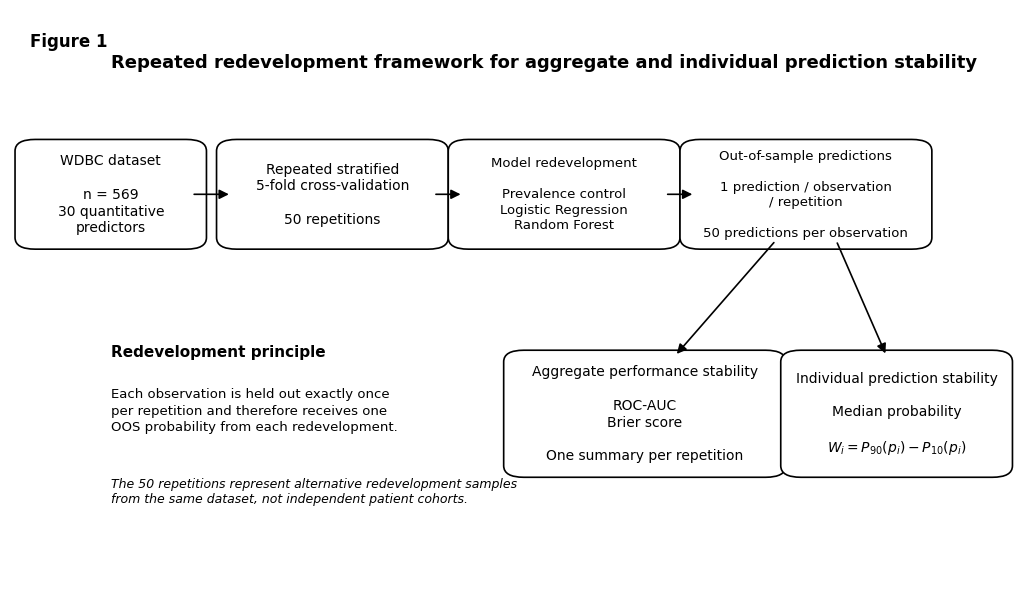

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ---------------------------------------------------------------------
# Output directory
# ---------------------------------------------------------------------

figures_dir = Path("artifacts/figures")
figures_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def add_box(ax, x, y, width, height, text, fontsize=10, linewidth=1.2):
    """Add a rounded rectangular box centered at (x, y)."""
    
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=linewidth,
        facecolor="white",
        edgecolor="black",
    )
    
    ax.add_patch(box)
    
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.25,
    )


def add_arrow(ax, start, end):
    """Add an arrow between two points."""
    
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2,
        color="black",
        shrinkA=2,
        shrinkB=2,
    )
    
    ax.add_patch(arrow)


# ---------------------------------------------------------------------
# Figure canvas
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


# ---------------------------------------------------------------------
# Main workflow
# ---------------------------------------------------------------------

add_box(
    ax,
    0.10,
    0.68,
    0.16,
    0.16,
    "WDBC dataset\n\nn = 569\n30 quantitative\npredictors",
    fontsize=10,
)

add_box(
    ax,
    0.32,
    0.68,
    0.20,
    0.16,
    "Repeated stratified\n5-fold cross-validation\n\n50 repetitions",
    fontsize=10,
)

add_box(
    ax,
    0.55,
    0.68,
    0.20,
    0.16,
    "Model redevelopment\n\nPrevalence control\nLogistic Regression\nRandom Forest",
    fontsize=9.5,
)

add_box(
    ax,
    0.79,
    0.68,
    0.22,
    0.16,
    "Out-of-sample predictions\n\n1 prediction / observation\n/ repetition\n\n50 predictions per observation",
    fontsize=9.5,
)


# Main arrows

add_arrow(ax, (0.18, 0.68), (0.22, 0.68))
add_arrow(ax, (0.42, 0.68), (0.45, 0.68))
add_arrow(ax, (0.65, 0.68), (0.68, 0.68))


# ---------------------------------------------------------------------
# Branch into the two stability levels
# ---------------------------------------------------------------------

add_box(
    ax,
    0.63,
    0.30,
    0.25,
    0.19,
    "Aggregate performance stability\n\nROC-AUC\nBrier score\n\nOne summary per repetition",
    fontsize=10,
)

add_box(
    ax,
    0.88,
    0.30,
    0.20,
    0.19,
    "Individual prediction stability\n\nMedian probability\n\n$W_i = P_{90}(p_i) - P_{10}(p_i)$",
    fontsize=10,
)


# Branching arrows from OOS predictions

add_arrow(ax, (0.76, 0.60), (0.66, 0.40))
add_arrow(ax, (0.82, 0.60), (0.87, 0.40))


# ---------------------------------------------------------------------
# Explanatory annotation
# ---------------------------------------------------------------------

ax.text(
    0.10,
    0.40,
    "Redevelopment principle",
    fontsize=11,
    fontweight="bold",
    ha="left",
)

ax.text(
    0.10,
    0.345,
    "Each observation is held out exactly once\n"
    "per repetition and therefore receives one\n"
    "OOS probability from each redevelopment.",
    fontsize=9.5,
    ha="left",
    va="top",
    linespacing=1.35,
)

ax.text(
    0.10,
    0.19,
    "The 50 repetitions represent alternative redevelopment samples\n"
    "from the same dataset, not independent patient cohorts.",
    fontsize=9,
    ha="left",
    va="top",
    style="italic",
)


# ---------------------------------------------------------------------
# Panel label / title
# ---------------------------------------------------------------------

ax.text(
    0.02,
    0.96,
    "Figure 1",
    fontsize=12,
    fontweight="bold",
    ha="left",
    va="top",
)

ax.text(
    0.10,
    0.90,
    "Repeated redevelopment framework for aggregate and individual prediction stability",
    fontsize=13,
    fontweight="bold",
    ha="left",
)


# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------

plt.savefig(
    figures_dir / "experimental_design_stability_framework.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "experimental_design_stability_framework.pdf",
    bbox_inches="tight",
)

plt.show()

**Figure 1. Experimental design for evaluating prediction stability under repeated model redevelopment.**  
The WDBC dataset (n = 569) was evaluated using 50 repetitions of stratified 5-fold cross-validation. Within each repetition, every observation was held out exactly once, yielding one out-of-sample predicted probability per observation and therefore 50 OOS probabilities per observation across redevelopment repetitions. Stability was evaluated at two complementary levels: aggregate predictive performance, summarized using ROC-AUC and Brier score across repetitions, and observation-level prediction stability, summarized using the median predicted probability and the central 80% resampling width, \(W_i=P_{90}(p_i)-P_{10}(p_i)\). The repeated cross-validation runs represent alternative redevelopment samples from the same dataset and are not treated as independent patient cohorts.

## Frozen data contract

Following the dataset audit, the analysis dataset is frozen before any model fitting.

The study will use:
- exactly 569 WDBC observations;
- exactly the 30 predefined quantitative morphology predictors;
- their original scikit-learn ordering;
- an explicitly recoded binary outcome where malignancy equals 1;
- stable project-specific observation IDs for tracking predictions.

No observations or predictors will be removed on the basis of subsequent model performance.

The dataset fingerprint and software versions have been recorded to detect unintended changes to the analysis input.

Any future modification of this data contract must be treated as a protocol change and documented explicitly rather than silently incorporated into the analysis.


# Stage 2: Resampling design

## Objective

The primary analysis uses repeated stratified 5-fold cross-validation.

Before generating all repetitions or fitting any model, the resampling procedure is audited independently.

Within each repetition:
- the 569 observations are divided into five non-overlapping test folds;
- each observation appears in exactly one test fold;
- the remaining four folds form the corresponding training set;
- no observation can be simultaneously present in train and test;
- class proportions are approximately preserved by stratification;
- exactly the same partitions will later be used for all modeling procedures.

In [11]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

# Audit configuration
N_SPLITS = 5
AUDIT_SEED = 20260923

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=AUDIT_SEED)
single_repeat_splits = list(cv.split(X_analysis, y_analysis))

# 1. Fold-level summary
fold_summary = []
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    y_train = y_analysis.iloc[train_idx]
    y_test = y_analysis.iloc[test_idx]
    
    fold_summary.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "train_malignant": int(y_train.sum()),
        "train_benign": int((y_train == 0).sum()),
        "test_malignant": int(y_test.sum()),
        "test_benign": int((y_test == 0).sum()),
        "train_malignant_prop": y_train.mean(),
        "test_malignant_prop": y_test.mean(),
    })

fold_summary_df = pd.DataFrame(fold_summary)
print("--- FOLD SUMMARY (1 REPETITION) ---")
print(fold_summary_df)

# 2. Audit train/test overlap
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    overlap = set(train_idx).intersection(test_idx)
    assert len(overlap) == 0, f"Train/test overlap detected in fold {fold}"

print("\n✓ No train/test overlap detected.")

# 3. Test and training-set appearances
test_counts = np.zeros(len(X_analysis), dtype=int)
train_counts = np.zeros(len(X_analysis), dtype=int)

for train_idx, test_idx in single_repeat_splits:
    test_counts[test_idx] += 1
    train_counts[train_idx] += 1

assert np.all(test_counts == 1), "Unexpected test-set count"
assert np.all(train_counts == N_SPLITS - 1), "Unexpected training-set count"

print("✓ Every observation appears exactly once in test.")
print("✓ Every observation appears in training exactly four times.")

# 4. Audit fold sizes and class balance
assert (fold_summary_df["n_test"].max() - fold_summary_df["n_test"].min() <= 1)
assert (fold_summary_df["test_malignant"].max() - fold_summary_df["test_malignant"].min() <= 1)
assert (fold_summary_df["test_benign"].max() - fold_summary_df["test_benign"].min() <= 1)

print("✓ Fold sizes and class counts are appropriately balanced.")

# 5. Fold-assignment table
fold_assignment = pd.DataFrame({
    "observation_id": ids_analysis.values,
    "malignant": y_analysis.values,
    "test_fold": -1
})

for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    fold_assignment.loc[test_idx, "test_fold"] = fold

assert (fold_assignment["test_fold"] >= 0).all()
assert fold_assignment["observation_id"].is_unique
print("✓ Fold assignment table is complete.")

--- FOLD SUMMARY (1 REPETITION) ---
   fold  n_train  n_test  train_malignant  train_benign  test_malignant  \
0     0      455     114              169           286              43   
1     1      455     114              169           286              43   
2     2      455     114              170           285              42   
3     3      455     114              170           285              42   
4     4      456     113              170           286              42   

   test_benign  train_malignant_prop  test_malignant_prop  
0           71              0.371429             0.377193  
1           71              0.371429             0.377193  
2           72              0.373626             0.368421  
3           72              0.373626             0.368421  
4           71              0.372807             0.371681  

✓ No train/test overlap detected.
✓ Every observation appears exactly once in test.
✓ Every observation appears in training exactly four times.
✓ Fold s

## Interpretation of one CV repetition

One 5-fold CV repetition generates five related model fits.

For each observation, only the model for which that observation belongs to the held-out fold is used to obtain its out-of-sample prediction.

After all five folds have been evaluated, the repetition produces a complete vector of 569 out-of-sample predictions:

$$\hat{\mathbf p}^{(r)} = (p_{1r}, p_{2r}, \dots, p_{569r}).$$

The five fitted models are not treated as independent experiments.

The purpose of the fold structure is to provide out-of-sample predictions for every observation while using approximately 80% of the observed dataset for each development fit.

In [12]:
from numpy.random import SeedSequence

N_REPEATS = 50
MASTER_RESAMPLING_SEED = 20260923

# Generate reproducible resampling seeds
seed_sequence = SeedSequence(MASTER_RESAMPLING_SEED)
repeat_seeds = [
    int(child.generate_state(1)[0])
    for child in seed_sequence.spawn(N_REPEATS)
]

assert len(repeat_seeds) == 50
assert len(set(repeat_seeds)) == 50
print("✓ Generated 50 unique reproducible resampling seeds.")

# Construct the complete resampling manifest
resampling_manifest = []

for repeat, seed in enumerate(repeat_seeds):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_analysis, y_analysis)):
        for idx in test_idx:
            resampling_manifest.append({
                "repeat": repeat,
                "seed": seed,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": idx,
                "malignant": int(y_analysis.iloc[idx]),
            })

resampling_manifest = pd.DataFrame(resampling_manifest)

# Critical resampling-manifest checks
assert len(resampling_manifest) == 569 * N_REPEATS, "Unexpected number of rows"

counts_per_case = resampling_manifest.groupby("observation_id").size()
assert (counts_per_case == N_REPEATS).all(), "Unexpected number of assignments for at least one observation"

counts_per_repeat = resampling_manifest.groupby("repeat").size()
assert (counts_per_repeat == 569).all(), "Unexpected number of observations in at least one repetition"

duplicates = resampling_manifest.duplicated(["repeat", "observation_id"]).sum()
assert duplicates == 0, "Duplicate repeat-observation assignments detected"

print(f"\n✓ Resampling manifest generated successfully! Shape: {resampling_manifest.shape}")
print("✓ Every observation has exactly one OOS assignment in every repetition.")
print("✓ Duplicate repeat-observation assignments: 0")

✓ Generated 50 unique reproducible resampling seeds.

✓ Resampling manifest generated successfully! Shape: (28450, 6)
✓ Every observation has exactly one OOS assignment in every repetition.
✓ Duplicate repeat-observation assignments: 0


## Frozen resampling contract

The primary resampling procedure was defined before fitting any predictive model.

Parameters:

- 5-fold stratified cross-validation
- shuffling enabled
- 50 initial repetitions
- one reproducible seed per repetition derived from a master resampling seed
- identical fold assignments for all modeling procedures
- exactly one out-of-sample assignment per observation and repetition
- 569 out-of-sample observations per repetition
- 28,450 total observation-repetition assignments

The repetitions are repeated realizations of the same prespecified
redevelopment procedure conditional on the observed WDBC dataset.

They are not treated as independent patient cohorts.

In [13]:
resampling_contract = {
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "stratified": True,
    "shuffle": True,
    "master_seed": MASTER_RESAMPLING_SEED,
    "same_splits_for_all_models": True,
}

resampling_contract

{'n_splits': 5,
 'n_repeats': 50,
 'stratified': True,
 'shuffle': True,
 'master_seed': 20260923,
 'same_splits_for_all_models': True}

In [14]:
from pathlib import Path

split_dir = Path("artifacts/splits")
split_dir.mkdir(parents=True, exist_ok=True)

manifest_path = split_dir / "resampling_manifest.csv"

resampling_manifest.to_csv(
    manifest_path,
    index=False
)

print("Saved:", manifest_path)

Saved: artifacts/splits/resampling_manifest.csv


In [15]:
import hashlib

with open(manifest_path, "rb") as f:
    manifest_sha256 = hashlib.sha256(f.read()).hexdigest()

print("Resampling manifest SHA-256:")
print(manifest_sha256)

Resampling manifest SHA-256:
d2bd8ab9e86c1d05dd4291954f873f13553068bcf02271f7fb873bd35089d499


# Stage 3 - Prevalence-only baseline

Testing the complete data-to-prediction pipeline using a naive null model:

$$\hat{p} = \frac{\# \text{malignant}_{\text{train}}}{n_{\text{train}}}$$

This model completely ignores predictor variables ($X$) and serves as a baseline check for infrastructure, calibration, and discrimination.

In [16]:
import numpy as np
import pandas as pd

prevalence_predictions = []

for repeat in range(N_REPEATS):
    repeat_manifest = resampling_manifest[resampling_manifest["repeat"] == repeat]

    for fold in range(N_SPLITS):
        fold_test = repeat_manifest[repeat_manifest["fold"] == fold]
        test_idx = fold_test["row_index"].to_numpy()

        # Construct the training set by excluding held-out indices
        train_mask = np.ones(len(y_analysis), dtype=bool)
        train_mask[test_idx] = False
        train_idx = np.where(train_mask)[0]

        # Compute prevalence strictly from the training set
        y_train = y_analysis.iloc[train_idx]
        train_prevalence = y_train.mean()

        for idx in test_idx:
            prevalence_predictions.append({
                "model": "prevalence",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(train_prevalence),
                "n_train": len(train_idx),
                "train_prevalence": float(train_prevalence),
            })

prevalence_predictions = pd.DataFrame(prevalence_predictions)
print("Prevalence predictions shape:", prevalence_predictions.shape)
prevalence_predictions.head()

Prevalence predictions shape: (28450, 9)


,model,repeat,fold,observation_id,row_index,y_true,predicted_probability,n_train,train_prevalence
0,prevalence,0,0,WDBC_004,4,1,0.371429,455,0.371429
1,prevalence,0,0,WDBC_006,6,1,0.371429,455,0.371429
2,prevalence,0,0,WDBC_007,7,1,0.371429,455,0.371429
3,prevalence,0,0,WDBC_010,10,1,0.371429,455,0.371429
4,prevalence,0,0,WDBC_021,21,0,0.371429,455,0.371429


In [17]:
# 1. Structural and dimensional checks
assert len(prevalence_predictions) == 569 * N_REPEATS
assert prevalence_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert prevalence_predictions["predicted_probability"].notna().all()
assert prevalence_predictions["predicted_probability"].between(0, 1).all()
assert prevalence_predictions.groupby("repeat").size().eq(569).all()
assert prevalence_predictions.groupby("observation_id").size().eq(N_REPEATS).all()

print("✓ Prevalence baseline OOS prediction checks passed.")

# 2. Data-leakage check (one prevalence value per fold)
predictions_per_fold = (
    prevalence_predictions
    .groupby(["repeat", "fold"])["predicted_probability"]
    .nunique()
)

assert (predictions_per_fold == 1).all()
print("✓ Each fold uses exactly one training-derived prevalence.")

✓ Prevalence baseline OOS prediction checks passed.
✓ Each fold uses exactly one training-derived prevalence.


In [18]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 1. Brier score by repetition
baseline_brier = (
    prevalence_predictions
    .groupby("repeat")
    .apply(lambda df: brier_score_loss(df["y_true"], df["predicted_probability"]))
    .rename("brier")
    .reset_index()
)

print("--- BRIER SCORE SUMMARY ---")
print(baseline_brier["brier"].describe())

# 2. Fold-level AUC check (must equal 0.5)
baseline_fold_auc = []
for (repeat, fold), df in prevalence_predictions.groupby(["repeat", "fold"]):
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])
    baseline_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": int(df["y_true"].sum()),
        "n_negative": int((df["y_true"] == 0).sum()),
    })

baseline_fold_auc = pd.DataFrame(baseline_fold_auc)

# Formal check: all 250 folds must have AUC = 0.5
auc_counts = baseline_fold_auc["auc"].value_counts()
print("\n--- FOLD AUC VALUE COUNTS ---")
print(auc_counts)

assert (baseline_fold_auc["auc"] == 0.5).all()

# 3. Repetition-level weighted AUC
def weighted_fold_auc(df):
    weights = df["n_positive"] * df["n_negative"]
    return np.average(df["auc"], weights=weights)

baseline_auc = (
    baseline_fold_auc
    .groupby("repeat")
    .apply(weighted_fold_auc)
    .rename("auc")
    .reset_index()
)

assert (baseline_auc["auc"] == 0.5).all()
print("\n✓ All 250 fold AUCs = 0.5")
print("✓ All 50 repetition AUCs = 0.5")

--- BRIER SCORE SUMMARY ---
count    5.000000e+01
mean     2.337738e-01
std      2.803737e-17
min      2.337738e-01
25%      2.337738e-01
50%      2.337738e-01
75%      2.337738e-01
max      2.337738e-01
Name: brier, dtype: float64



--- FOLD AUC VALUE COUNTS ---
auc
0.5    250
Name: count, dtype: int64

✓ All 250 fold AUCs = 0.5
✓ All 50 repetition AUCs = 0.5


In [19]:
baseline_individual = (
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .agg(
        median_probability="median",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90),
        prediction_variance="var",
    )
)

baseline_individual["resampling_width"] = (
    baseline_individual["p90"] - baseline_individual["p10"]
)

print("--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(baseline_individual["resampling_width"].describe())

--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.002198
std        0.000000
min        0.002198
25%        0.002198
50%        0.002198
75%        0.002198
max        0.002198
Name: resampling_width, dtype: float64


Verification one more time...


In [20]:
(
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .nunique()
    .value_counts()
)

predicted_probability
3    569
Name: count, dtype: int64

In [21]:
np.sort(
    prevalence_predictions["predicted_probability"].unique()
)

array([0.37142857, 0.37280702, 0.37362637])

## Prevalence-only baseline: interpretation

The prevalence-only control behaved as expected.

Across all 250 held-out folds, ROC-AUC was exactly 0.5 because every
observation within a fold receives the same training-derived probability.

The repetition-level Brier score was effectively identical across all
50 repetitions. This occurs because stratified five-fold cross-validation
preserves nearly identical class counts across folds; the prevalence-only
model depends exclusively on those counts rather than on observation identity.

Individual prediction resampling widths were also identical across all
569 observations ($W_i \approx 0.00220$). This reflects the narrow range of
training-set malignancy prevalences permitted by the stratified fold
structure.

This control demonstrates that prediction stability and predictive utility
are distinct properties: a prediction procedure can be highly stable while
having no discriminatory ability.

# Stage 4: Logistic Regression

## Prespecified learning procedure

The first predictive model is a fixed L2-regularized logistic regression.

Predictors are standardized using statistics estimated exclusively from the
corresponding training fold.

The prespecified procedure is:

- `StandardScaler`
- L2-regularized logistic regression
- `C = 1.0`
- `solver = "lbfgs"`
- `max_iter = 5000`
- no class weighting
- no feature selection
- no hyperparameter tuning

Under scikit-learn >= 1.8, the default `l1_ratio = 0.0`
corresponds to pure L2 regularization. The deprecated `penalty`
argument is therefore not explicitly specified.

All preprocessing and fitting occur strictly within the training portion of
each fold.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# 1. Define the fixed pipeline without deprecated or inactive arguments
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000
    ))
])

## Generate all 28,450 LR OOS predictions

We generate out-of-sample (OOS) predictions across all 50 repetitions (250 fold fits) using the frozen `resampling_manifest`.

To prevent state leakage across folds, we define a factory function `make_lr_pipeline()` that produces a fresh instance of the prespecified `StandardScaler` + `LogisticRegression` pipeline for every fit.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Define the fixed Logistic Regression pipeline
def make_lr_pipeline():
    """Return a fresh Pipeline instance for each fold to prevent state carryover."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

lr_predictions = []
lr_fit_diagnostics = []

for repeat in range(N_REPEATS):

    repeat_manifest = resampling_manifest[
        resampling_manifest["repeat"] == repeat
    ]

    for fold in range(N_SPLITS):

        fold_test = repeat_manifest[
            repeat_manifest["fold"] == fold
        ]

        test_idx = fold_test["row_index"].to_numpy(dtype=int)

        train_mask = np.ones(len(X_analysis), dtype=bool)
        train_mask[test_idx] = False

        train_idx = np.where(train_mask)[0]

        # Explicit no-overlap check
        assert len(np.intersect1d(train_idx, test_idx)) == 0

        X_train = X_analysis.iloc[train_idx]
        X_test = X_analysis.iloc[test_idx]
        y_train = y_analysis.iloc[train_idx]

        model = make_lr_pipeline()
        model.fit(X_train, y_train)

        # Verify positive class explicitly
        classes = model.named_steps["model"].classes_
        assert np.array_equal(classes, np.array([0, 1]))

        malignant_idx = np.flatnonzero(classes == 1).item()

        p_test = model.predict_proba(X_test)[:, malignant_idx]

        # Basic prediction checks
        assert len(p_test) == len(test_idx)
        assert np.isfinite(p_test).all()
        assert ((p_test >= 0) & (p_test <= 1)).all()

        # Training-only scaler check
        np.testing.assert_allclose(
            model.named_steps["scaler"].mean_,
            X_train.mean(axis=0).to_numpy()
        )

        n_iter = int(model.named_steps["model"].n_iter_[0])

        lr_fit_diagnostics.append({
            "repeat": repeat,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_iter": n_iter,
        })

        for idx, prob in zip(test_idx, p_test):
            lr_predictions.append({
                "model": "logistic_regression",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(prob),
            })

lr_predictions = pd.DataFrame(lr_predictions)
lr_fit_diagnostics = pd.DataFrame(lr_fit_diagnostics)

### Audit the first frozen resampling split

For consistency with the full analysis, the first audited fold is reconstructed
directly from the frozen resampling manifest.

The manifest stores one row per out-of-sample observation rather than storing
training-index arrays explicitly. The test indices for repetition 0, fold 0
are therefore extracted from `row_index`, and the corresponding training set
is defined as their complement.

In [24]:
print(resampling_manifest.columns.tolist())
print(resampling_manifest.shape)
display(resampling_manifest.head())

['repeat', 'seed', 'fold', 'observation_id', 'row_index', 'malignant']
(28450, 6)


,repeat,seed,fold,observation_id,row_index,malignant
0,0,1900052506,0,WDBC_004,4,1
1,0,1900052506,0,WDBC_006,6,1
2,0,1900052506,0,WDBC_007,7,1
3,0,1900052506,0,WDBC_010,10,1
4,0,1900052506,0,WDBC_021,21,0


In [25]:
# Reconstruct repetition 0, fold 0 directly from the frozen manifest

first_fold_manifest = resampling_manifest[
    (resampling_manifest["repeat"] == 0)
    & (resampling_manifest["fold"] == 0)
].copy()

test_idx_audit = (
    first_fold_manifest["row_index"]
    .to_numpy(dtype=int)
)

train_mask_audit = np.ones(
    len(X_analysis),
    dtype=bool
)

train_mask_audit[test_idx_audit] = False

train_idx_audit = np.flatnonzero(
    train_mask_audit
)

# Structural checks
assert len(test_idx_audit) in {113, 114}
assert len(train_idx_audit) + len(test_idx_audit) == 569

assert len(
    np.intersect1d(
        train_idx_audit,
        test_idx_audit
    )
) == 0

assert set(train_idx_audit).union(
    set(test_idx_audit)
) == set(range(len(X_analysis)))

print("Train size:", len(train_idx_audit))
print("Test size:", len(test_idx_audit))
print("✓ First frozen split reconstructed directly from resampling_manifest.")

Train size: 455
Test size: 114
✓ First frozen split reconstructed directly from resampling_manifest.


### Prediction Table, Convergence, and Manifest Audit

Before evaluating performance metrics, we verify structural invariants:
1. **Dimensions & Completeness:** Exactly 28,450 OOS predictions (569 observations $\times$ 50 repetitions).
2. **Convergence:** Every single L-BFGS optimizer fit converged well below `max_iter=5000`.
3. **Manifest Alignment:** The exact alignment of predictions against the frozen resampling manifest.

In [26]:
# Stage 4D.1 - Audit table shape and invariants
print("Prediction table shape:", lr_predictions.shape)
print("Fit diagnostics shape:", lr_fit_diagnostics.shape)

assert len(lr_predictions) == 569 * N_REPEATS
assert lr_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert lr_predictions.groupby("repeat").size().eq(569).all()
assert lr_predictions.groupby("observation_id").size().eq(N_REPEATS).all()
assert lr_predictions["predicted_probability"].notna().all()
assert lr_predictions["predicted_probability"].between(0, 1).all()
assert len(lr_fit_diagnostics) == 250

# Stage 4D.2 - Convergence audit
print("Maximum optimizer iterations used:", lr_fit_diagnostics["n_iter"].max())
assert (lr_fit_diagnostics["n_iter"] < 5000).all()

# Stage 4D.3 — Verify predictions match the frozen manifest
manifest_keys = (
    resampling_manifest[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

prediction_keys = (
    lr_predictions[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(manifest_keys, prediction_keys)

print("✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.")

Prediction table shape: (28450, 7)
Fit diagnostics shape: (250, 5)
Maximum optimizer iterations used: 22
✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.


## Global Performance Metrics

We compute repetition-level Brier scores and ROC-AUC scores using fully vectorized Pandas aggregations:

- **Brier Score:** Evaluated per repetition across all 569 OOS predictions:
  $$\text{Brier}_r = \frac{1}{N} \sum_{i=1}^{N} (y_{ir} - p_{ir})^2$$
- **Repetition ROC-AUC:** Weighted average of fold-level ROC-AUCs using pair weights $w_{rk} = n_{+,rk} \cdot n_{-,rk}$:
  $$\text{AUC}_r = \frac{\sum_k w_{rk} \text{AUC}_{rk}}{\sum_k w_{rk}}$$

In [27]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 4E.1 — Vectorized Brier score
lr_brier = (
    lr_predictions
    .assign(squared_error=lambda df: (df["y_true"] - df["predicted_probability"]) ** 2)
    .groupby("repeat", as_index=False)
    .agg(brier=("squared_error", "mean"))
)

# Sanity Check punctual con Scikit-Learn (solo Repetition 0)
check_df = lr_predictions[lr_predictions["repeat"] == 0]
check_sklearn = brier_score_loss(check_df["y_true"], check_df["predicted_probability"])
check_vec = lr_brier.loc[lr_brier["repeat"] == 0, "brier"].item()
np.testing.assert_allclose(check_sklearn, check_vec)
print("✓ Vectorized Brier matches sklearn.")

# 4E.2 — Fold-specific ROC-AUC
lr_fold_auc = []
for (repeat, fold), df in lr_predictions.groupby(["repeat", "fold"]):
    n_positive = int(df["y_true"].sum())
    n_negative = int((df["y_true"] == 0).sum())
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])

    lr_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "pair_weight": n_positive * n_negative,
    })

lr_fold_auc = pd.DataFrame(lr_fold_auc)
assert len(lr_fold_auc) == 250
assert lr_fold_auc["auc"].between(0, 1).all()

# 4E.3 — Vectorized weighted repetition AUC
lr_auc = (
    lr_fold_auc
    .assign(weighted_auc=lambda df: df["auc"] * df["pair_weight"])
    .groupby("repeat", as_index=False)
    .agg(
        weighted_auc_sum=("weighted_auc", "sum"),
        total_pair_weight=("pair_weight", "sum"),
    )
)
lr_auc["auc"] = lr_auc["weighted_auc_sum"] / lr_auc["total_pair_weight"]
lr_auc = lr_auc[["repeat", "auc"]]

✓ Vectorized Brier matches sklearn.


## Individual Prediction Stability

For each observation $i \in \{1, \dots, 569\}$, we extract the 50 OOS predicted probabilities $\{p_{i1}, \dots, p_{i50}\}$ and compute our primary prediction stability estimand:
$$W_i = P_{90}(p_i) - P_{10}(p_i)$$

Quantiles are explicitly calculated using `method="linear"`.

In [28]:
def q10(x):
    return np.quantile(x.to_numpy(), 0.10, method="linear")

def q90(x):
    return np.quantile(x.to_numpy(), 0.90, method="linear")

lr_individual = (
    lr_predictions
    .groupby("observation_id")
    .agg(
        y_true=("y_true", "first"),
        median_probability=("predicted_probability", "median"),
        p10=("predicted_probability", q10),
        p90=("predicted_probability", q90),
        prediction_variance=("predicted_probability", "var"),
        n_oos_predictions=("predicted_probability", "size"),
    )
    .reset_index()
)

lr_individual["resampling_width"] = (
    lr_individual["p90"] - lr_individual["p10"]
)

# Audit Individual Table
assert len(lr_individual) == 569
assert (lr_individual["n_oos_predictions"] == 50).all()
assert (lr_individual["resampling_width"] >= 0).all()
assert lr_individual["median_probability"].between(0, 1).all()
assert lr_individual["p10"].between(0, 1).all()
assert lr_individual["p90"].between(0, 1).all()

print("✓ Individual LR stability table validated.")

✓ Individual LR stability table validated.


## Visualizing Prediction Stability vs. Median Probability

We plot the median OOS predicted probability $\text{Median}(p_i)$ against the individual resampling width $W_i$. 

This directly explores whether prediction instability is concentrated around boundary/intermediate probabilities or if it extends into extreme predictions.

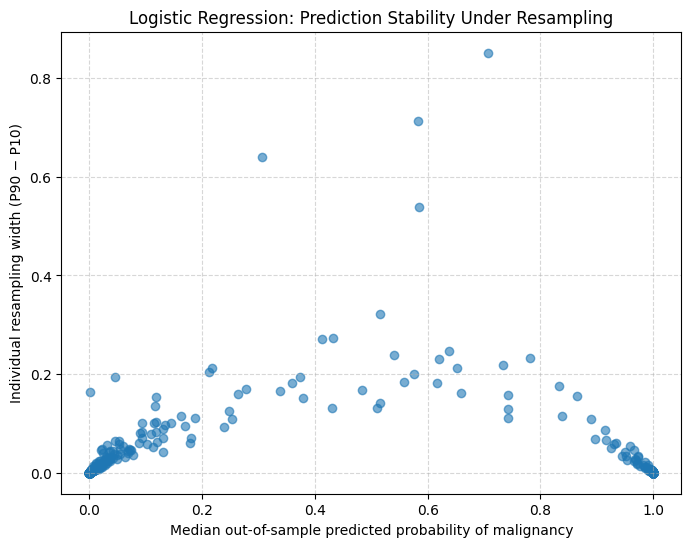


--- 1. OPTIMIZER ITERATIONS SUMMARY ---
count    250.000000
mean      18.360000
std        1.546599
min       14.000000
25%       17.000000
50%       18.000000
75%       20.000000
max       22.000000
Name: n_iter, dtype: float64

--- 2. BRIER SCORE SUMMARY ---
count    50.000000
mean      0.020547
std       0.001677
min       0.017014
25%       0.019437
50%       0.020540
75%       0.021681
max       0.024350
Name: brier, dtype: float64

--- 3. REPETITION-LEVEL AUC SUMMARY ---
count    50.000000
mean      0.994556
std       0.001299
min       0.990156
25%       0.994136
50%       0.994715
75%       0.995375
max       0.996564
Name: auc, dtype: float64

--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.025813
std        0.074385
min        0.000000
10%        0.000001
25%        0.000073
50%        0.001004
75%        0.012490
90%        0.072620
95%        0.157334
99%        0.271392
max        0.851826
Name: resampling_width, dtype: float64


In [29]:
import matplotlib.pyplot as plt

# 1. Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(
    lr_individual["median_probability"],
    lr_individual["resampling_width"],
    alpha=0.6
)
plt.xlabel("Median out-of-sample predicted probability of malignancy")
plt.ylabel("Individual resampling width (P90 − P10)")
plt.title("Logistic Regression: Prediction Stability Under Resampling")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Print the four requested analysis outputs
print("\n--- 1. OPTIMIZER ITERATIONS SUMMARY ---")
print(lr_fit_diagnostics["n_iter"].describe())

print("\n--- 2. BRIER SCORE SUMMARY ---")
print(lr_brier["brier"].describe())

print("\n--- 3. REPETITION-LEVEL AUC SUMMARY ---")
print(lr_auc["auc"].describe())

print("\n--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(lr_individual["resampling_width"].describe(
    percentiles=[.10, .25, .50, .75, .90, .95, .99]
))

## Inspection of Top Instability Cases

To better understand the right tail of the $W_i$ distribution, we inspect the 10 most sensitive observations and examine the full empirical distribution of $OOS$ predicted probabilities across the 50 repetitions for the 3 most extreme cases.

This allows us to distinguish between a **gradual dispersion** in predictions versus a **bimodal/discontinuous jump** caused by specific training perturbations.

In [30]:
# 1. Table of the 10 observations with the largest W_i
top10_lr = (
    lr_individual
    .sort_values("resampling_width", ascending=False)
    .head(10)
    [[
        "observation_id",
        "y_true",
        "median_probability",
        "p10",
        "p90",
        "resampling_width",
        "prediction_variance",
    ]]
)

print("--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---")
print(top10_lr.to_string(index=False))

# 2. Inspect all 50 predictions for the three most unstable observations
top3_ids = lr_individual.nlargest(3, "resampling_width")["observation_id"].tolist()

print("\n--- FULL 50 OOS PREDICTED PROBABILITIES FOR TOP 3 CASES ---")
for obs_id in top3_ids:
    values = (
        lr_predictions
        .loc[lr_predictions["observation_id"] == obs_id, "predicted_probability"]
        .sort_values()
        .to_numpy()
    )
    print(f"\nObservation ID: {obs_id}")
    print(np.round(values, 4))

--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---
observation_id  y_true  median_probability      p10      p90  resampling_width  prediction_variance
      WDBC_038       1            0.706837 0.042433 0.894260          0.851826             0.104935
      WDBC_068       0            0.582392 0.176582 0.889993          0.713412             0.069829
      WDBC_190       1            0.305278 0.132610 0.772342          0.639732             0.052532
      WDBC_146       1            0.584808 0.272325 0.810990          0.538665             0.038735
      WDBC_238       0            0.516281 0.370478 0.692961          0.322483             0.014637
      WDBC_157       0            0.432844 0.304906 0.577976          0.273071             0.011815
      WDBC_455       0            0.413379 0.325616 0.596218          0.270602             0.012830
      WDBC_541       0            0.637519 0.519081 0.765913          0.246832             0.009351
      WDBC_013       1            0.539891 0.401128 

## Monte-Carlo Precision Diagnostic for Primary Stability Summaries

Before concluding Stage 4, we evaluate whether $R = 50$ repetitions are numerically sufficient to produce stable estimates of our primary cohort-level stability summaries:
- $\text{Median}(W_i)$
- $P_{90}(W_i)$

We draw $B = 2,000$ non-parametric Monte-Carlo resamples of the **repetitions** (resampling complete columns of the $569 \times 50$ probability matrix). 

> **Note:** This diagnostic quantifies the *approximation error* introduced by using 50 realizations instead of an infinite number of repetitions; it is **not** a population confidence interval.

In [31]:
# 1. Probability matrix (569 observations × 50 repetitions)
lr_probability_matrix = (
    lr_predictions
    .pivot(
        index="observation_id",
        columns="repeat",
        values="predicted_probability"
    )
)

assert lr_probability_matrix.shape == (569, 50)

# 2. Resampling Monte-Carlo
MC_BOOTSTRAPS = 2000
MC_SEED = 20260924

rng = np.random.default_rng(MC_SEED)
mc_results = []
P = lr_probability_matrix.to_numpy()

for b in range(MC_BOOTSTRAPS):
    sampled_repeats = rng.integers(0, P.shape[1], size=P.shape[1])
    Pb = P[:, sampled_repeats]

    p10_b = np.quantile(Pb, 0.10, axis=1, method="linear")
    p90_b = np.quantile(Pb, 0.90, axis=1, method="linear")
    widths_b = p90_b - p10_b

    mc_results.append({
        "median_width": np.median(widths_b),
        "p90_width": np.quantile(widths_b, 0.90, method="linear"),
    })

mc_results = pd.DataFrame(mc_results)

# 3. Monte Carlo precision summary
mc_summary = pd.DataFrame({
    "estimate": [
        lr_individual["resampling_width"].median(),
        lr_individual["resampling_width"].quantile(0.90),
    ],
    "MC_SE": [
        mc_results["median_width"].std(ddof=1),
        mc_results["p90_width"].std(ddof=1),
    ],
    "MC_P2.5": [
        mc_results["median_width"].quantile(0.025),
        mc_results["p90_width"].quantile(0.025),
    ],
    "MC_P97.5": [
        mc_results["median_width"].quantile(0.975),
        mc_results["p90_width"].quantile(0.975),
    ],
}, index=["median_W", "P90_W"])

print("--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---")
print(mc_summary)

--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---
          estimate     MC_SE   MC_P2.5  MC_P97.5
median_W  0.001004  0.000036  0.000931  0.001068
P90_W     0.072620  0.004159  0.067244  0.083122


## Monte Carlo precision of the primary stability summaries

The numerical precision of the individual-stability summaries was evaluated
by resampling complete redevelopment repetitions.

With 50 repetitions:

- median individual resampling width:
  `0.001004`, Monte Carlo SE `0.000036`;

- 90th percentile individual resampling width:
  `0.072620`, Monte Carlo SE `0.004159`.

The corresponding Monte Carlo diagnostic ranges were approximately
`0.000931–0.001068` for the median and `0.067244–0.083122` for the
90th percentile.

These ranges quantify numerical sensitivity to the finite number of
redevelopment repetitions. They are not confidence intervals for a patient
population or for an individual's true probability.

The precision was considered sufficient for the descriptive cohort-level
objectives of Project 1, so the prespecified initial 50 repetitions were
retained.

In [32]:
lr_individual["central80_crosses_05"] = (
    (lr_individual["p10"] < 0.5)
    &
    (lr_individual["p90"] > 0.5)
)

print(
    lr_individual["central80_crosses_05"]
    .value_counts()
)

print(
    "\nProportion:",
    lr_individual["central80_crosses_05"].mean()
)

central80_crosses_05
False    555
True      14
Name: count, dtype: int64

Proportion: 0.02460456942003515


### Threshold-crossing sensitivity

For 14 of 569 observations (2.46%), the central 80% resampling interval
(P10–P90) crossed the reference threshold of 0.5.

This quantity is descriptive only. The threshold of 0.5 has no claimed
clinical decision meaning in this study.

The result illustrates why probability stability is the primary object of
interest: substantial changes in predicted probability can occur without
necessarily producing a change in binary classification.

## Stage 4 checkpoint

At this checkpoint, the following components have been completed before
analysis of the Random Forest procedure:

- dataset provenance and structural audit;
- frozen analysis data contract;
- frozen repeated stratified 5-fold resampling design;
- prevalence-only control;
- prespecified L2 logistic-regression procedure;
- 28,450 genuine out-of-sample logistic-regression predictions;
- aggregate ROC-AUC and Brier-score stability analysis;
- individual prediction resampling-width analysis;
- Monte Carlo precision assessment for the primary stability summaries;
- descriptive inspection of highly resampling-sensitive observations.

No Random Forest results have been examined at this stage.

# Stage 5 - Random Forest

## Stage 5A: Prespecified learning procedure

The Random Forest procedure was frozen in `protocol/analysis_plan_v1.md` before inspection of any Random Forest results.

The starting configuration for the prespecified escalation rule is:

- `n_estimators = 2000`
- `criterion = "gini"`
- `max_depth = None`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = "sqrt"`
- `bootstrap = True`
- `max_samples = None`
- `class_weight = None`
- primary random seed = `20260925`
- no feature selection
- no hyperparameter tuning

Unlike Logistic Regression, Random Forest contains internal algorithmic randomness. The primary seed is therefore fixed so that the main resampling experiment primarily reflects changes in training-sample composition.

Before running the full repeated-CV experiment, we first assessed how much residual randomness remained from the finite size of the Random Forest ensemble. This diagnostic was performed on the first frozen outer split, using the same split each time, so that only the Random Forest seed varied.

The prespecified escalation rule was 2,000 → 4,000 → 8,000 trees. We started with 2,000 trees and computed the standard deviation of the predicted probability for each test observation across five prespecified diagnostic seeds. If the 90th percentile of these seed-induced standard deviations was ≤ 0.005, that forest size was retained. If the tolerance was exceeded, the same diagnostic was repeated with 4,000 trees, and then with 8,000 trees if needed.

Escalation stopped at 8,000 trees. The retained forest size was then used uniformly throughout the primary repeated-CV experiment, while the primary model seed and all other Random Forest parameters remained fixed. This decision was based only on finite-forest prediction variability; no predictive-performance metric was used to choose the forest size.


In [33]:
from sklearn.ensemble import RandomForestClassifier

MASTER_RF_SEED = 20260925
RF_N_ESTIMATORS = 2000


def make_rf_model(random_state=MASTER_RF_SEED, n_estimators=RF_N_ESTIMATORS):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        max_samples=None,
        class_weight=None,
        random_state=random_state,
        n_jobs=-1,
    )

## Stage 5B: Audit one frozen Random Forest fit

Before running the complete 250-fit experiment, we perform a structural audit on a single outer split (Repeat 0, Fold 0). 

To enforce absolute consistency with the protocol contract, training and test indices are derived strictly from `resampling_manifest` rather than any temporary or auxiliary split objects.

This step verifies:
1. Exact row index alignment between the manifest and the dataset.
2. Complete non-overlap between training and test indices.
3. Correct class alignment (`model.classes_ == [0, 1]`) to ensure probabilities explicitly denote malignancy ($Y=1$).

In [34]:
RF_AUDIT_REPEAT = 0
RF_AUDIT_FOLD = 0

audit_test_rows = resampling_manifest[
    (resampling_manifest["repeat"] == RF_AUDIT_REPEAT)
    & (resampling_manifest["fold"] == RF_AUDIT_FOLD)
]

test_idx = audit_test_rows["row_index"].to_numpy(dtype=int)

train_mask = np.ones(len(X_analysis), dtype=bool)
train_mask[test_idx] = False
train_idx = np.where(train_mask)[0]

# Structural checks
assert len(np.intersect1d(train_idx, test_idx)) == 0
assert len(train_idx) + len(test_idx) == len(X_analysis)

X_train = X_analysis.iloc[train_idx]
X_test = X_analysis.iloc[test_idx]

y_train = y_analysis.iloc[train_idx]
y_test = y_analysis.iloc[test_idx]

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train malignant:", int(y_train.sum()))
print("Test malignant:", int(y_test.sum()))

Train size: 455
Test size: 114
Train malignant: 169
Test malignant: 43


In [35]:
rf_model = make_rf_model()
rf_model.fit(X_train, y_train)

print("Model classes:", rf_model.classes_)
print("Number of trees:", len(rf_model.estimators_))

Model classes: [0 1]
Number of trees: 2000


In [36]:
assert np.array_equal(rf_model.classes_, np.array([0, 1]))

malignant_class_index = np.flatnonzero(rf_model.classes_ == 1).item()

rf_p_test = rf_model.predict_proba(X_test)[:, malignant_class_index]

assert len(rf_p_test) == len(test_idx)
assert np.isfinite(rf_p_test).all()
assert ((rf_p_test >= 0) & (rf_p_test <= 1)).all()

print("✓ First frozen-fold RF malignant probabilities are valid.\n")
print(pd.Series(rf_p_test, name="predicted_probability").describe())

✓ First frozen-fold RF malignant probabilities are valid.

count    114.000000
mean       0.350272
std        0.433866
min        0.000000
25%        0.001125
50%        0.041000
75%        0.895750
max        1.000000
Name: predicted_probability, dtype: float64


## Stage 5C: Finite-forest randomness diagnostic

Random Forest predictions are subject to Monte Carlo variability induced by the random selection of bootstrap samples and candidate splitting features. 

The primary scientific question asks how predictions respond to **training-sample changes**. Therefore, we must verify that algorithmic variability (changing the random seed on the *exact same* training data) is negligibly small relative to the probability scale.

### Diagnostic Protocol
1. Keep the training set ($N_{\text{train}} = 455$) and held-out test set ($N_{\text{test}} = 114$) fixed.
2. Refit Random Forest across 5 prespecified diagnostic seeds: `101, 202, 303, 404, 505`.
3. Compute the per-observation standard deviation of predicted probabilities across the 5 realizations.
4. Evaluate $P_{90}(\text{SD})$ against the prespecified computational tolerance:
$$P_{90}(\text{seed-induced prediction SD}) \le 0.005$$

### Stage 5C.1 - Finite-forest randomness diagnostic (2,000 trees)

We evaluate the per-observation seed-induced standard deviation across 5 prespecified diagnostic seeds (`101, 202, 303, 404, 505`) on the first frozen split using the primary configuration of `n_estimators = 2000`.

In [37]:
RF_DIAGNOSTIC_SEEDS = [101, 202, 303, 404, 505]
rf_seed_predictions = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions.append(probs)


rf_seed_predictions = np.column_stack(
    rf_seed_predictions
)

assert rf_seed_predictions.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

# Sanity check
assert not np.allclose(
    rf_seed_predictions[:, 0],
    rf_seed_predictions[:, 1]
)
print("✓ Different RF seeds produce distinct finite-forest realizations.\n")

# Statistical summary for 2000 trees
rf_seed_sd = rf_seed_predictions.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary = (
    pd.Series(
        rf_seed_sd,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90 = np.quantile(
    rf_seed_sd,
    0.90,
    method="linear"
)

RF_RANDOMNESS_TOLERANCE = 0.005

print("--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 2000 TREES ---")
print(rf_seed_sd_summary)
print(f"\nP90 seed-induced prediction SD: {rf_seed_sd_p90:.6f}")
print(f"Prespecified tolerance:         {RF_RANDOMNESS_TOLERANCE:.6f}")

✓ Different RF seeds produce distinct finite-forest realizations.

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 2000 TREES ---
count    114.000000
mean       0.002967
std        0.003582
min        0.000000
50%        0.001405
90%        0.008233
95%        0.010109
99%        0.014923
max        0.015602
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.008233
Prespecified tolerance:         0.005000


### Stage 5C.2 - Evaluation of the frozen decision rule for 2,000 trees

Using the first frozen outer split and five prespecified Random Forest seeds, the 90th percentile of the per-observation seed-induced prediction standard deviation was:

`P90 = 0.008233`

This exceeded the prespecified computational tolerance:

`P90 <= 0.005`.

According to the frozen protocol, 2,000 trees were therefore not retained for the primary Random Forest experiment, and the diagnostic was repeated with 4,000 trees.

This decision is based solely on the prespecified finite-forest randomness criterion and not on predictive performance.

### Stage 5C.3 - Repeat diagnostic with 4,000 trees

Following the frozen decision rule, we repeat the diagnostic using `n_estimators = 4000` while holding all other experimental parameters identical:
- Same training and test partition ($N_{\text{train}}=455$, $N_{\text{test}}=114$).
- Same diagnostic seeds (`101, 202, 303, 404, 505`).
- Same model hyperparameters and outcome coding.
- Same computational tolerance ($P_{90} \le 0.005$).

In [38]:
RF_N_ESTIMATORS_4000 = 4000

rf_seed_predictions_4000 = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS_4000
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions_4000.append(probs)


rf_seed_predictions_4000 = np.column_stack(
    rf_seed_predictions_4000
)

assert rf_seed_predictions_4000.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

In [39]:
rf_seed_sd_4000 = rf_seed_predictions_4000.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary_4000 = (
    pd.Series(
        rf_seed_sd_4000,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90_4000 = np.quantile(
    rf_seed_sd_4000,
    0.90,
    method="linear"
)

print(
    "--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 4000 TREES ---"
)

print(rf_seed_sd_summary_4000)

print(
    f"\nP90 seed-induced prediction SD: "
    f"{rf_seed_sd_p90_4000:.6f}"
)

print(
    f"Prespecified tolerance:         "
    f"{RF_RANDOMNESS_TOLERANCE:.6f}"
)

if rf_seed_sd_p90_4000 <= RF_RANDOMNESS_TOLERANCE:

    print(
        "\n✓ 4000 trees satisfy the prespecified "
        "finite-forest randomness criterion."
    )

else:

    print(
        "\n✗ 4000 trees exceed the prespecified "
        "finite-forest randomness criterion."
    )

    print(
        "According to the frozen protocol, "
        "repeat the diagnostic with 8000 trees."
    )

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 4000 TREES ---
count    114.000000
mean       0.001995
std        0.002291
min        0.000000
50%        0.001141
90%        0.005394
95%        0.007312
99%        0.008500
max        0.010564
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.005394
Prespecified tolerance:         0.005000

✗ 4000 trees exceed the prespecified finite-forest randomness criterion.
According to the frozen protocol, repeat the diagnostic with 8000 trees.


In [40]:
comparison = pd.DataFrame({
    "n_estimators": [2000, 4000],
    "median_seed_SD": [
        np.median(rf_seed_sd),
        np.median(rf_seed_sd_4000)
    ],
    "P90_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.90,
            method="linear"
        ),
    ],
    "P95_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.95,
            method="linear"
        ),
    ],
    "P99_seed_SD": [
        rf_seed_sd_summary.loc["99%"],
        rf_seed_sd_summary_4000.loc["99%"],
    ],

    "max_seed_SD": [
        rf_seed_sd.max(),
        rf_seed_sd_4000.max()
    ],
})

comparison

,n_estimators,median_seed_SD,P90_seed_SD,P95_seed_SD,P99_seed_SD,max_seed_SD
0,2000,0.001405,0.008233,0.010109,0.014923,0.015602
1,4000,0.001141,0.005394,0.007312,0.008500,0.010564


### Finite-forest randomness diagnostic: 4,000 trees

Increasing the forest from 2,000 to 4,000 trees reduced seed-induced
prediction variability.

The 90th percentile of the per-observation prediction SD decreased from:

`0.008233` at 2,000 trees

to:

`0.005394` at 4,000 trees.

However, this remained slightly above the prespecified computational
tolerance:

`P90 <= 0.005`.

According to the frozen protocol, the diagnostic was therefore repeated
with 8,000 trees.

No predictive-performance metric was used in this decision.

### Stage 5C.4 - Finite-forest randomness diagnostic (8,000 trees)

In [41]:
RF_N_ESTIMATORS_8000 = 8000

rf_seed_predictions_8000 = []

for seed in RF_DIAGNOSTIC_SEEDS:

    model = make_rf_model(
        random_state=seed,
        n_estimators=RF_N_ESTIMATORS_8000
    )

    model.fit(
        X_train,
        y_train
    )

    assert np.array_equal(
        model.classes_,
        np.array([0, 1])
    )

    malignant_idx = np.flatnonzero(
        model.classes_ == 1
    ).item()

    probs = model.predict_proba(
        X_test
    )[:, malignant_idx]

    assert len(probs) == len(test_idx)
    assert np.isfinite(probs).all()
    assert ((probs >= 0) & (probs <= 1)).all()

    rf_seed_predictions_8000.append(probs)


rf_seed_predictions_8000 = np.column_stack(
    rf_seed_predictions_8000
)

assert rf_seed_predictions_8000.shape == (
    len(test_idx),
    len(RF_DIAGNOSTIC_SEEDS)
)

In [42]:
rf_seed_sd_8000 = rf_seed_predictions_8000.std(
    axis=1,
    ddof=1
)

rf_seed_sd_summary_8000 = (
    pd.Series(
        rf_seed_sd_8000,
        name="seed_induced_prediction_sd"
    )
    .describe(
        percentiles=[
            .50,
            .90,
            .95,
            .99
        ]
    )
)

rf_seed_sd_p90_8000 = np.quantile(
    rf_seed_sd_8000,
    0.90,
    method="linear"
)

print(
    "--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 8000 TREES ---"
)

print(rf_seed_sd_summary_8000)

print(
    f"\nP90 seed-induced prediction SD: "
    f"{rf_seed_sd_p90_8000:.6f}"
)

print(
    f"Prespecified tolerance:         "
    f"{RF_RANDOMNESS_TOLERANCE:.6f}"
)

if rf_seed_sd_p90_8000 <= RF_RANDOMNESS_TOLERANCE:

    print(
        "\n✓ 8000 trees satisfy the prespecified "
        "finite-forest randomness criterion."
    )

else:

    print(
        "\n✗ 8000 trees still exceed the prespecified "
        "finite-forest randomness criterion."
    )

    print(
        "The protocol maximum has been reached. "
        "Residual algorithmic variability must be reported."
    )

--- RF FINITE-FOREST RANDOMNESS DIAGNOSTIC: 8000 TREES ---
count    114.000000
mean       0.001328
std        0.001569
min        0.000000
50%        0.000631
90%        0.003893
95%        0.004655
99%        0.005913
max        0.006756
Name: seed_induced_prediction_sd, dtype: float64

P90 seed-induced prediction SD: 0.003893
Prespecified tolerance:         0.005000

✓ 8000 trees satisfy the prespecified finite-forest randomness criterion.


In [43]:
comparison = pd.DataFrame({
    "n_estimators": [
        2000,
        4000,
        8000
    ],

    "median_seed_SD": [
        np.median(rf_seed_sd),
        np.median(rf_seed_sd_4000),
        np.median(rf_seed_sd_8000),
    ],

    "P90_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.90,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_8000,
            0.90,
            method="linear"
        ),
    ],

    "P95_seed_SD": [
        np.quantile(
            rf_seed_sd,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_4000,
            0.95,
            method="linear"
        ),
        np.quantile(
            rf_seed_sd_8000,
            0.95,
            method="linear"
        ),
    ],

    "P99_seed_SD": [
        rf_seed_sd_summary.loc["99%"],
        rf_seed_sd_summary_4000.loc["99%"],
        rf_seed_sd_summary_8000.loc["99%"],
    ],

    "max_seed_SD": [
        rf_seed_sd.max(),
        rf_seed_sd_4000.max(),
        rf_seed_sd_8000.max(),
    ],
})

comparison

,n_estimators,median_seed_SD,P90_seed_SD,P95_seed_SD,P99_seed_SD,max_seed_SD
0,2000,0.001405,0.008233,0.010109,0.014923,0.015602
1,4000,0.001141,0.005394,0.007312,0.008500,0.010564
2,8000,0.000631,0.003893,0.004655,0.005913,0.006756


### Final finite-forest randomness diagnostic

Residual Random Forest algorithmic variability decreased as the number of trees increased:

| Trees | Median seed SD | P90 seed SD | P95 seed SD | P99 seed SD | Maximum seed SD |
|------:|---------------:|------------:|------------:|------------:|----------------:|
| 2,000 | 0.001405 | 0.008233 | 0.010109 | 0.014923 | 0.015602 |
| 4,000 | 0.001141 | 0.005394 | 0.007312 | 0.008500 | 0.010564 |
| 8,000 | 0.000631 | 0.003893 | 0.004655 | 0.005913 | 0.006756 |

The prespecified criterion was:

`P90(seed-induced prediction SD) <= 0.005`.

The 2,000-tree and 4,000-tree forests exceeded this tolerance, whereas the 8,000-tree forest satisfied it (`P90 = 0.003893`).

According to the frozen protocol, 8,000 trees were therefore retained for the primary Random Forest resampling analysis.

This decision was based exclusively on the prespecified finite-forest randomness diagnostic and not on predictive performance.

Residual algorithmic variability is not assumed to be zero; rather, it was reduced below the predefined computational tolerance.

In [44]:
RF_N_ESTIMATORS = 8000


def make_rf_model(
    random_state=MASTER_RF_SEED,
    n_estimators=RF_N_ESTIMATORS
):

    return RandomForestClassifier(
        n_estimators=n_estimators,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        max_samples=None,
        class_weight=None,
        random_state=random_state,
        n_jobs=-1,
    )

## Stage 5D: Generate all Random Forest out-of-sample predictions

The final Random Forest configuration selected by the prespecified finite-forest randomness diagnostic uses 8,000 trees.

The complete primary Random Forest experiment now applies this frozen procedure to the same 50 × 5-fold resampling manifest used for Logistic Regression.

For every repetition and fold:

1. the held-out observations are obtained directly from the frozen resampling manifest;
2. the training set is defined as the complementary observations;
3. a fresh 8,000-tree Random Forest is fitted using the fixed primary RF seed;
4. each held-out observation receives one genuine out-of-sample predicted probability of malignancy.

The procedure produces:

569 observations × 50 repetitions = 28,450 OOS predictions

from:

50 repetitions × 5 folds = 250 fitted forests.

No predictive-performance metric is inspected until the full OOS prediction table has passed structural validation.

In [45]:
RF_N_ESTIMATORS = 8000
MASTER_RF_SEED = 20260925

rf_check = make_rf_model()

assert rf_check.n_estimators == 8000
assert rf_check.random_state == MASTER_RF_SEED
assert rf_check.max_features == "sqrt"
assert rf_check.bootstrap is True
assert rf_check.class_weight is None

print("✓ Final primary RF configuration confirmed.")

✓ Final primary RF configuration confirmed.


In [46]:
import time

rf_predictions = []
rf_fit_diagnostics = []

total_fits = N_REPEATS * N_SPLITS
fit_counter = 0

stage5d_start = time.perf_counter()

for repeat in range(N_REPEATS):

    repeat_manifest = resampling_manifest[
        resampling_manifest["repeat"] == repeat
    ]

    for fold in range(N_SPLITS):

        fit_counter += 1

        fold_test = repeat_manifest[
            repeat_manifest["fold"] == fold
        ]

        test_idx = (
            fold_test["row_index"]
            .to_numpy(dtype=int)
        )

        # Training set = exact complement of frozen test fold
        train_mask = np.ones(
            len(X_analysis),
            dtype=bool
        )
        train_mask[test_idx] = False

        train_idx = np.where(train_mask)[0]

        # Structural checks before fitting
        assert len(
            np.intersect1d(train_idx, test_idx)
        ) == 0

        assert (
            len(train_idx) + len(test_idx)
            == len(X_analysis)
        )

        X_train = X_analysis.iloc[train_idx]
        X_test = X_analysis.iloc[test_idx]

        y_train = y_analysis.iloc[train_idx]
        y_test = y_analysis.iloc[test_idx]

        # Verify manifest outcome matches frozen analysis outcome
        manifest_y = (
            fold_test
            .sort_values("row_index")
            ["malignant"]
            .to_numpy()
        )

        analysis_y = (
            y_analysis.iloc[
                np.sort(test_idx)
            ]
            .to_numpy()
        )

        np.testing.assert_array_equal(
            manifest_y,
            analysis_y
        )

        # Fresh forest for every fold
        model = make_rf_model(
            random_state=MASTER_RF_SEED,
            n_estimators=RF_N_ESTIMATORS
        )

        fit_start = time.perf_counter()

        model.fit(
            X_train,
            y_train
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        # Explicit positive-class check
        assert np.array_equal(
            model.classes_,
            np.array([0, 1])
        )

        malignant_idx = np.flatnonzero(
            model.classes_ == 1
        ).item()

        p_test = model.predict_proba(
            X_test
        )[:, malignant_idx]

        # Prediction checks
        assert len(p_test) == len(test_idx)
        assert np.isfinite(p_test).all()
        assert ((p_test >= 0) & (p_test <= 1)).all()

        assert len(model.estimators_) == RF_N_ESTIMATORS

        # Fit-level diagnostics
        rf_fit_diagnostics.append({
            "repeat": repeat,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_estimators": len(model.estimators_),
            "fit_seconds": fit_seconds,
        })

        # OOS predictions
        for idx, prob in zip(
            test_idx,
            p_test
        ):

            rf_predictions.append({
                "model": "random_forest",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(
                    y_analysis.iloc[idx]
                ),
                "predicted_probability": float(prob),
            })

    # Lightweight progress indicator
    elapsed_minutes = (
        time.perf_counter()
        - stage5d_start
    ) / 60

    print(
        f"Completed repetition "
        f"{repeat + 1}/{N_REPEATS} "
        f"({fit_counter}/{total_fits} fits) "
        f"| elapsed: {elapsed_minutes:.1f} min"
    )


rf_predictions = pd.DataFrame(
    rf_predictions
)

rf_fit_diagnostics = pd.DataFrame(
    rf_fit_diagnostics
)

stage5d_minutes = (
    time.perf_counter()
    - stage5d_start
) / 60

print(
    f"\n✓ Stage 5D completed in "
    f"{stage5d_minutes:.1f} minutes."
)

Completed repetition 1/50 (5/250 fits) | elapsed: 0.4 min


Completed repetition 2/50 (10/250 fits) | elapsed: 0.8 min


Completed repetition 3/50 (15/250 fits) | elapsed: 1.2 min


Completed repetition 4/50 (20/250 fits) | elapsed: 1.6 min


Completed repetition 5/50 (25/250 fits) | elapsed: 2.0 min


...

Completed repetition 46/50 (230/250 fits) | elapsed: 18.1 min


Completed repetition 47/50 (235/250 fits) | elapsed: 18.6 min


Completed repetition 48/50 (240/250 fits) | elapsed: 19.0 min


Completed repetition 49/50 (245/250 fits) | elapsed: 19.4 min


Completed repetition 50/50 (250/250 fits) | elapsed: 19.8 min

✓ Stage 5D completed in 19.8 minutes.


In [47]:
print(
    "Prediction table shape:",
    rf_predictions.shape
)

print(
    "Fit diagnostics shape:",
    rf_fit_diagnostics.shape
)

assert len(rf_predictions) == (
    569 * N_REPEATS
)

assert len(rf_fit_diagnostics) == (
    N_REPEATS * N_SPLITS
)

assert (
    rf_predictions[
        ["repeat", "observation_id"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    rf_predictions
    .groupby("repeat")
    .size()
    .eq(569)
    .all()
)

assert (
    rf_predictions
    .groupby("observation_id")
    .size()
    .eq(N_REPEATS)
    .all()
)

assert (
    rf_predictions[
        "predicted_probability"
    ]
    .notna()
    .all()
)

assert (
    rf_predictions[
        "predicted_probability"
    ]
    .between(0, 1)
    .all()
)

assert (
    rf_fit_diagnostics[
        "n_estimators"
    ]
    .eq(8000)
    .all()
)

print(
    "✓ All 28,450 RF predictions satisfy "
    "the primary structural invariants."
)

Prediction table shape: (28450, 7)
Fit diagnostics shape: (250, 6)
✓ All 28,450 RF predictions satisfy the primary structural invariants.


In [48]:
manifest_keys = (
    resampling_manifest[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

rf_prediction_keys = (
    rf_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    manifest_keys,
    rf_prediction_keys
)

print(
    "✓ RF predictions correspond exactly "
    "to the frozen resampling manifest."
)

✓ RF predictions correspond exactly to the frozen resampling manifest.


In [49]:
lr_keys = (
    lr_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
            "y_true",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

rf_keys = (
    rf_predictions[
        [
            "repeat",
            "fold",
            "observation_id",
            "row_index",
            "y_true",
        ]
    ]
    .sort_values(
        [
            "repeat",
            "fold",
            "row_index",
        ]
    )
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    lr_keys,
    rf_keys
)

print(
    "✓ LR and RF use exactly the same "
    "observation × repetition × fold assignments."
)

✓ LR and RF use exactly the same observation × repetition × fold assignments.


In [50]:
print(
    "--- RF FIT-TIME SUMMARY ---"
)

print(
    rf_fit_diagnostics[
        "fit_seconds"
    ].describe()
)

--- RF FIT-TIME SUMMARY ---
count    250.000000
mean       4.376071
std        0.209020
min        4.086883
25%        4.204943
50%        4.345312
75%        4.488222
max        5.209643
Name: fit_seconds, dtype: float64


In [51]:
import hashlib
from pathlib import Path


# ==========================================================
# Output paths
# ==========================================================

prediction_dir = Path(
    "artifacts/predictions"
)

prediction_dir.mkdir(
    parents=True,
    exist_ok=True
)

diagnostic_dir = Path("artifacts/diagnostics")
diagnostic_dir.mkdir(parents=True, exist_ok=True)

rf_prediction_path = (
    prediction_dir
    / "random_forest_oos_predictions.csv"
)

rf_diagnostics_path = (
    diagnostic_dir
    / "random_forest_fit_diagnostics.csv"
)

rf_diagnostics_deterministic_path = (
    diagnostic_dir
    / "random_forest_fit_diagnostics_deterministic.csv"
)


# ==========================================================
# Save complete prediction and diagnostic artifacts
# ==========================================================

rf_predictions.to_csv(
    rf_prediction_path,
    index=False
)

rf_fit_diagnostics.to_csv(
    rf_diagnostics_path,
    index=False
)


# ==========================================================
# Deterministic RF diagnostics artifact
# ==========================================================
#
# Wall-clock fit time is retained in the complete diagnostics
# file but excluded from the reproducibility fingerprint because
# execution time depends on hardware and system load.

rf_fit_diagnostics_deterministic = (
    rf_fit_diagnostics[
        [
            "repeat",
            "fold",
            "n_train",
            "n_test",
            "n_estimators",
        ]
    ]
    .sort_values(
        ["repeat", "fold"]
    )
    .reset_index(drop=True)
)

rf_fit_diagnostics_deterministic.to_csv(
    rf_diagnostics_deterministic_path,
    index=False,
    lineterminator="\n"
)


print(
    "Saved:",
    rf_prediction_path
)

print(
    "Saved:",
    rf_diagnostics_path
)

print(
    "Saved:",
    rf_diagnostics_deterministic_path
)


# ==========================================================
# SHA256 fingerprints
# ==========================================================

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


rf_prediction_sha256 = sha256_file(
    rf_prediction_path
)

rf_diagnostics_deterministic_sha256 = sha256_file(
    rf_diagnostics_deterministic_path
)


print(
    "RF prediction SHA256:",
    rf_prediction_sha256
)

print(
    "RF deterministic diagnostics SHA256:",
    rf_diagnostics_deterministic_sha256
)


# ==========================================================
# File sizes
# ==========================================================

print(
    f"Predictions size: "
    f"{rf_prediction_path.stat().st_size / 1024**2:.2f} MB"
)

print(
    f"Diagnostics size: "
    f"{rf_diagnostics_path.stat().st_size / 1024**2:.2f} MB"
)

Saved: artifacts/predictions/random_forest_oos_predictions.csv
Saved: artifacts/diagnostics/random_forest_fit_diagnostics.csv
Saved: artifacts/diagnostics/random_forest_fit_diagnostics_deterministic.csv
RF prediction SHA256: 7b3570fa69710f8e7bdf73031858e319b26992663a51cd5a92c367b864339420
RF deterministic diagnostics SHA256: 7ab807d0f803fcc6ad905f530428849a657d8aefc25480ef62a4995b86636701
Predictions size: 1.13 MB
Diagnostics size: 0.01 MB


## Stage 5E & 5F: Random Forest Aggregate Performance & Resampling Stability

With the 28,450 out-of-sample predictions generated, we analyze Random Forest's performance in isolation using the exact same metrics and definitions applied to Logistic Regression:

1. Brier Score per repetition.
2. Weighted Fold-AUC per repetition (weighted by the number of valid pairs $n_+ \times n_-$ per fold).
3. Observation-level Resampling Stability measured by $P_{90} - P_{10}$ across the 50 repetitions.

In [52]:
from sklearn.metrics import brier_score_loss

rf_brier = (
    rf_predictions
    .assign(
        squared_error=lambda df:
            (df["y_true"] - df["predicted_probability"]) ** 2
    )
    .groupby("repeat", as_index=False)
    .agg(
        brier=("squared_error", "mean")
    )
)

# Sanity check against sklearn for repetition 0
check_df = rf_predictions[
    rf_predictions["repeat"] == 0
]

check_sklearn = brier_score_loss(
    check_df["y_true"],
    check_df["predicted_probability"]
)

check_vectorized = rf_brier.loc[
    rf_brier["repeat"] == 0,
    "brier"
].item()

np.testing.assert_allclose(
    check_sklearn,
    check_vectorized
)

print("✓ RF vectorized Brier matches sklearn.")
print("\n--- RF BRIER SCORE SUMMARY (50 REPETITIONS) ---")
print(rf_brier["brier"].describe())

✓ RF vectorized Brier matches sklearn.

--- RF BRIER SCORE SUMMARY (50 REPETITIONS) ---
count    50.000000
mean      0.031696
std       0.001008
min       0.029944
25%       0.031040
50%       0.031524
75%       0.032236
max       0.034994
Name: brier, dtype: float64


In [53]:
from sklearn.metrics import roc_auc_score

rf_fold_auc = []

for (repeat, fold), df in rf_predictions.groupby(["repeat", "fold"]):
    n_positive = int(df["y_true"].sum())
    n_negative = int((df["y_true"] == 0).sum())

    auc = roc_auc_score(
        df["y_true"],
        df["predicted_probability"]
    )

    rf_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "pair_weight": n_positive * n_negative,
    })

rf_fold_auc = pd.DataFrame(rf_fold_auc)

assert len(rf_fold_auc) == 250
assert rf_fold_auc["auc"].between(0, 1).all()

# Weighted AUC per repetition
rf_auc = (
    rf_fold_auc
    .assign(
        weighted_auc=lambda df:
            df["auc"] * df["pair_weight"]
    )
    .groupby("repeat", as_index=False)
    .agg(
        weighted_auc_sum=("weighted_auc", "sum"),
        total_pair_weight=("pair_weight", "sum"),
    )
)

rf_auc["auc"] = (
    rf_auc["weighted_auc_sum"]
    / rf_auc["total_pair_weight"]
)

rf_auc = rf_auc[["repeat", "auc"]]

print("\n--- RF WEIGHTED FOLD-AUC SUMMARY (50 REPETITIONS) ---")
print(rf_auc["auc"].describe())


--- RF WEIGHTED FOLD-AUC SUMMARY (50 REPETITIONS) ---
count    50.000000
mean      0.990640
std       0.000924
min       0.987744
25%       0.989999
50%       0.990701
75%       0.991246
max       0.992303
Name: auc, dtype: float64


In [54]:
def q10(x):
    return np.quantile(x, 0.10, method="linear")


def q90(x):
    return np.quantile(x, 0.90, method="linear")


rf_individual = (
    rf_predictions
    .groupby("observation_id")
    .agg(
        y_true=("y_true", "first"),
        median_probability=(
            "predicted_probability",
            "median"
        ),
        p10=(
            "predicted_probability",
            q10
        ),
        p90=(
            "predicted_probability",
            q90
        ),
        prediction_variance=(
            "predicted_probability",
            "var"
        ),
        n_oos_predictions=(
            "predicted_probability",
            "size"
        ),
    )
    .reset_index()
)

rf_individual["resampling_width"] = (
    rf_individual["p90"]
    - rf_individual["p10"]
)

assert len(rf_individual) == 569
assert rf_individual["n_oos_predictions"].eq(N_REPEATS).all()

print("\n--- RF INDIVIDUAL RESAMPLING WIDTH (P90 - P10) SUMMARY ---")
print(
    rf_individual["resampling_width"].describe(
        percentiles=[
            .10, .25, .50, .75,
            .90, .95, .99
        ]
    )
)


--- RF INDIVIDUAL RESAMPLING WIDTH (P90 - P10) SUMMARY ---
count    569.000000
mean       0.033779
std        0.047609
min        0.000000
10%        0.000625
25%        0.002137
50%        0.010450
75%        0.052187
90%        0.107858
95%        0.128518
99%        0.181158
max        0.347762
Name: resampling_width, dtype: float64


## Post-hoc exploratory cross-procedure analyses

The primary analyses specified in `protocol/analysis_plan_v1.md` focus on
aggregate-performance stability and observation-level resampling widths for
each learning procedure.

Stages 5G–5J are post-hoc/exploratory. The primary summary table included in Stage 5G only restates prespecified endpoints and does not make these comparisons prespecified. Stages 5K–5M present the prespecified primary outputs; Stage 5N is a separate post-hoc robustness analysis.

The following cross-procedure analyses were added after inspection of the
primary Logistic Regression and Random Forest results. They are therefore
reported explicitly as post-hoc descriptive analyses.

These analyses include:

- paired observation-level comparison of resampling widths;
- cross-procedure Spearman rank concordance;
- top-decile overlap and Jaccard similarity;
- robustness of upper-tail membership to finite resampling repetitions;
- sensitivity to the sample-quantile convention.

They are intended to characterize the observed structure of instability and
do not redefine the primary study endpoints.

## Stage 5G: Paired comparison of learning procedures (post-hoc/exploratory)

Logistic Regression and Random Forest were evaluated using exactly the same
50 × 5-fold resampling manifest.

Aggregate metrics can therefore be aligned by redevelopment repetition.

The purpose of this comparison is descriptive: to characterize whether the
two learning procedures show similar or different patterns of aggregate
resampling sensitivity.

Repeated CV realizations are not treated as independent population samples,
so no conventional significance tests are performed.


In [55]:
aggregate_comparison = (
    lr_auc
    .rename(columns={"auc": "lr_auc"})
    .merge(
        rf_auc.rename(columns={"auc": "rf_auc"}),
        on="repeat",
        validate="one_to_one"
    )
    .merge(
        lr_brier.rename(columns={"brier": "lr_brier"}),
        on="repeat",
        validate="one_to_one"
    )
    .merge(
        rf_brier.rename(columns={"brier": "rf_brier"}),
        on="repeat",
        validate="one_to_one"
    )
)

assert len(aggregate_comparison) == 50

aggregate_comparison["auc_difference_rf_minus_lr"] = (
    aggregate_comparison["rf_auc"]
    - aggregate_comparison["lr_auc"]
)

aggregate_comparison["brier_difference_rf_minus_lr"] = (
    aggregate_comparison["rf_brier"]
    - aggregate_comparison["lr_brier"]
)

print("✓ Aggregate metrics aligned across all 50 repetitions.")

✓ Aggregate metrics aligned across all 50 repetitions.


In [56]:
print("--- PAIRED AUC DIFFERENCE: RF - LR ---")
print(
    aggregate_comparison[
        "auc_difference_rf_minus_lr"
    ].describe()
)

print("\n--- PAIRED BRIER DIFFERENCE: RF - LR ---")
print(
    aggregate_comparison[
        "brier_difference_rf_minus_lr"
    ].describe()
)

--- PAIRED AUC DIFFERENCE: RF - LR ---
count    50.000000
mean     -0.003916
std       0.001275
min      -0.006541
25%      -0.004872
50%      -0.003815
75%      -0.003303
max      -0.000595
Name: auc_difference_rf_minus_lr, dtype: float64

--- PAIRED BRIER DIFFERENCE: RF - LR ---
count    50.000000
mean      0.011149
std       0.001453
min       0.008438
25%       0.010360
50%       0.011030
75%       0.012206
max       0.014293
Name: brier_difference_rf_minus_lr, dtype: float64


### Primary aggregate and individual stability summary

The predefined primary summaries are reported side by side for the two
learning procedures.

Aggregate performance and individual prediction widths are not placed on a
common numerical scale; the table is intended to describe their respective
resampling behavior rather than construct a single stability score.

In [57]:
primary_summary = pd.DataFrame({
    "procedure": [
        "Logistic Regression",
        "Random Forest"
    ],
    "mean_auc": [
        lr_auc["auc"].mean(),
        rf_auc["auc"].mean(),
    ],
    "sd_auc": [
        lr_auc["auc"].std(),
        rf_auc["auc"].std(),
    ],
    "mean_brier": [
        lr_brier["brier"].mean(),
        rf_brier["brier"].mean(),
    ],
    "sd_brier": [
        lr_brier["brier"].std(),
        rf_brier["brier"].std(),
    ],
    "median_W": [
        lr_individual["resampling_width"].median(),
        rf_individual["resampling_width"].median(),
    ],
    "P90_W": [
        np.quantile(lr_individual["resampling_width"], 0.90, method="linear"),
        np.quantile(rf_individual["resampling_width"], 0.90, method="linear"),
    ],
    "P95_W": [
        np.quantile(lr_individual["resampling_width"], 0.95, method="linear"),
        np.quantile(rf_individual["resampling_width"], 0.95, method="linear"),
    ],
    "max_W": [
        lr_individual["resampling_width"].max(),
        rf_individual["resampling_width"].max(),
    ],
})
primary_summary


,procedure,mean_auc,sd_auc,mean_brier,sd_brier,median_W,P90_W,P95_W,max_W
0,Logistic Regression,0.994556,0.001299,0.020547,0.001677,0.001004,0.072620,0.157334,0.851826
1,Random Forest,0.990640,0.000924,0.031696,0.001008,0.010450,0.107858,0.128518,0.347762


### Observation-level comparison

Because the same 569 observations are evaluated under both learning
procedures, individual resampling widths can also be aligned observation by
observation.

This analysis asks whether prediction instability appears similarly across
the two procedures or whether it depends strongly on the learning algorithm.

In [58]:
individual_comparison = (
    lr_individual[
        [
            "observation_id",
            "y_true",
            "median_probability",
            "resampling_width",
        ]
    ]
    .rename(columns={
        "median_probability":
            "lr_median_probability",
        "resampling_width":
            "lr_resampling_width",
    })
    .merge(
        rf_individual[
            [
                "observation_id",
                "y_true",
                "median_probability",
                "resampling_width",
            ]
        ].rename(columns={
            "median_probability":
                "rf_median_probability",
            "resampling_width":
                "rf_resampling_width",
        }),
        on=[
            "observation_id",
            "y_true"
        ],
        validate="one_to_one",
    )
)

assert len(individual_comparison) == 569

individual_comparison[
    "width_difference_rf_minus_lr"
] = (
    individual_comparison["rf_resampling_width"]
    -
    individual_comparison["lr_resampling_width"]
)

print(
    individual_comparison[
        "width_difference_rf_minus_lr"
    ].describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
)

count    569.000000
mean       0.007966
std        0.060672
min       -0.599587
10%       -0.013041
25%        0.000367
50%        0.003917
75%        0.021749
90%        0.056073
95%        0.078341
99%        0.130758
max        0.340398
Name: width_difference_rf_minus_lr, dtype: float64


### Cross-procedure concordance of individual instability

A case may be highly resampling-sensitive under one learning procedure but
stable under another.

To assess whether instability tends to occur in the same observations across
models, the rank association between Logistic Regression and Random Forest
resampling widths is calculated.

This is a descriptive concordance measure; no population-level significance
test is interpreted.

In [59]:
from scipy.stats import spearmanr

rho, _ = spearmanr(
    individual_comparison[
        "lr_resampling_width"
    ],
    individual_comparison[
        "rf_resampling_width"
    ],
)

print(
    f"Spearman correlation between "
    f"LR and RF W_i: {rho:.4f}"
)

Spearman correlation between LR and RF W_i: 0.7275


## Stage 5H: Cross-procedure divergence in individual prediction stability (post-hoc/exploratory)

Although Logistic Regression and Random Forest show substantial concordance
in observation-level resampling sensitivity, their instability magnitudes are
not identical.

This stage examines where the two procedures disagree most strongly.

The analysis is descriptive. Extreme observations are inspected to understand
the structure of cross-procedure disagreement, not to define new instability
subgroups or thresholds.


In [60]:
### Direction of observation-level stability differences

n_rf_higher = (
    individual_comparison["width_difference_rf_minus_lr"] > 0
).sum()

n_lr_higher = (
    individual_comparison["width_difference_rf_minus_lr"] < 0
).sum()

n_equal = (
    individual_comparison["width_difference_rf_minus_lr"] == 0
).sum()

direction_summary = pd.DataFrame({
    "direction": [
        "RF width > LR width",
        "LR width > RF width",
        "Equal width"
    ],
    "n": [
        n_rf_higher,
        n_lr_higher,
        n_equal
    ]
})

direction_summary["proportion"] = (
    direction_summary["n"]
    / len(individual_comparison)
)

print("--- DIRECTION OF RESAMPLING WIDTH DIFFERENCES (RF - LR) ---")
print(direction_summary.to_string(index=False))

--- DIRECTION OF RESAMPLING WIDTH DIFFERENCES (RF - LR) ---
          direction   n  proportion
RF width > LR width 463    0.813708
LR width > RF width 106    0.186292
        Equal width   0    0.000000


In [61]:
### Observations with the largest cross-procedure disagreements

rf_more_sensitive = (
    individual_comparison
    .sort_values(
        "width_difference_rf_minus_lr",
        ascending=False
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "lr_median_probability",
            "rf_median_probability",
            "lr_resampling_width",
            "rf_resampling_width",
            "width_difference_rf_minus_lr",
        ]
    ]
)

lr_more_sensitive = (
    individual_comparison
    .sort_values(
        "width_difference_rf_minus_lr",
        ascending=True
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "lr_median_probability",
            "rf_median_probability",
            "lr_resampling_width",
            "rf_resampling_width",
            "width_difference_rf_minus_lr",
        ]
    ]
)

print("--- TOP 10 OBSERVATIONS WHERE RANDOM FOREST IS MORE SENSITIVE ---")
print(rf_more_sensitive.to_string(index=False))

print("\n--- TOP 10 OBSERVATIONS WHERE LOGISTIC REGRESSION IS MORE SENSITIVE ---")
print(lr_more_sensitive.to_string(index=False))

--- TOP 10 OBSERVATIONS WHERE RANDOM FOREST IS MORE SENSITIVE ---
observation_id  y_true  lr_median_probability  rf_median_probability  lr_resampling_width  rf_resampling_width  width_difference_rf_minus_lr
      WDBC_191       0               0.004607               0.345000             0.007364             0.347762                      0.340398
      WDBC_424       0               0.002890               0.176375             0.003618             0.171462                      0.167845
      WDBC_379       1               0.994307               0.640125             0.007467             0.165438                      0.157971
      WDBC_209       0               0.021601               0.319250             0.017843             0.171275                      0.153432
      WDBC_275       0               0.031997               0.252875             0.056720             0.198088                      0.141367
      WDBC_406       0               0.102639               0.552188             0.05792

In [62]:
### Upper-tail overlap of resampling-sensitive observations

n_top = int(
    np.ceil(
        0.10 * len(individual_comparison)
    )
)

lr_top10_ids = set(
    individual_comparison
    .nlargest(
        n_top,
        "lr_resampling_width"
    )
    ["observation_id"]
)

rf_top10_ids = set(
    individual_comparison
    .nlargest(
        n_top,
        "rf_resampling_width"
    )
    ["observation_id"]
)

top10_overlap = (
    lr_top10_ids
    & rf_top10_ids
)

top10_union = (
    lr_top10_ids
    | rf_top10_ids
)

upper_tail_summary = pd.DataFrame({
    "quantity": [
        "Top-decile observations per procedure",
        "Shared top-decile observations",
        "Proportion of LR top decile also in RF top decile",
        "Jaccard overlap"
    ],
    "value": [
        n_top,
        len(top10_overlap),
        len(top10_overlap) / len(lr_top10_ids),
        len(top10_overlap) / len(top10_union),
    ]
})

print("--- UPPER-TAIL OVERLAP SUMMARY (TOP 10% RESAMPLING WIDTH) ---")
print(upper_tail_summary.to_string(index=False))

--- UPPER-TAIL OVERLAP SUMMARY (TOP 10% RESAMPLING WIDTH) ---
                                         quantity     value
            Top-decile observations per procedure 57.000000
                   Shared top-decile observations 32.000000
Proportion of LR top decile also in RF top decile  0.561404
                                  Jaccard overlap  0.390244


## Stage 5I: Robustness of upper-tail concordance (post-hoc/exploratory)

The post-hoc exploratory cross-procedure analysis showed substantial cross-procedure concordance in
observation-level resampling width, including 32 shared observations among
the 57 most unstable observations under each procedure (56.1% overlap;
Jaccard index = 0.390).

Because top-decile membership depends on resampling widths estimated from
50 repetitions, this post-hoc robustness analysis evaluates how sensitive
the upper-tail concordance is to the finite number of resampling repetitions.

Using the same subset of repetitions for both learning procedures, resampling
widths are recomputed from repeated subsets of 20, 30, and 40 of the original
50 repetitions.

For each subset we evaluate:

1. the Jaccard overlap between the LR and RF top-decile sets;
2. recovery of each procedure's full-50-repetition top-decile set;
3. the frequency with which each observation is classified in the top decile.

This analysis evaluates Monte Carlo robustness conditional on the 50
realized resampling repetitions. It does not establish generalizability
beyond the observed WDBC dataset.


In [63]:
lr_matrix = (
    lr_predictions
    .pivot(
        index="observation_id",
        columns="repeat",
        values="predicted_probability"
    )
    .sort_index()
)

rf_matrix = (
    rf_predictions
    .pivot(
        index="observation_id",
        columns="repeat",
        values="predicted_probability"
    )
    .sort_index()
)

assert lr_matrix.shape == (569, 50)
assert rf_matrix.shape == (569, 50)

assert lr_matrix.index.equals(rf_matrix.index)
assert lr_matrix.columns.equals(rf_matrix.columns)

assert lr_matrix.notna().all().all()
assert rf_matrix.notna().all().all()

print("✓ LR and RF prediction matrices aligned.")
print("Shape:", lr_matrix.shape)

✓ LR and RF prediction matrices aligned.
Shape: (569, 50)


### Stage 5I.2: Audit of the top-decile cutoff

Before subsampling the 50 resampling repetitions, we verify that the
top-decile ranking is numerically well defined.

Because 10% of 569 observations corresponds to 56.9 cases, the upper-tail
set is defined as the 57 observations with the largest resampling widths.

For each learning procedure, we inspect the resampling widths at ranks
57 and 58. An exact or numerically indistinguishable tie across this
boundary would make membership in the top-57 set ambiguous.

We also independently reconstruct the full-50-repetition top-decile sets
from the prediction matrices and verify that they reproduce the previously
observed overlap of 32 observations and Jaccard index of 0.390244.

In [64]:
# Stage 5I.2 — Audit top-57 cutoff and reproduce full-sample overlap

observation_ids = lr_matrix.index.to_numpy()

lr_array = lr_matrix.to_numpy()
rf_array = rf_matrix.to_numpy()

n_observations = len(observation_ids)
n_top = int(np.ceil(0.10 * n_observations))

assert n_observations == 569
assert n_top == 57


def compute_widths(prediction_matrix):
    q10_values = np.quantile(
        prediction_matrix,
        0.10,
        axis=1,
        method="linear",
    )

    q90_values = np.quantile(
        prediction_matrix,
        0.90,
        axis=1,
        method="linear",
    )

    return q90_values - q10_values


lr_width_full = compute_widths(lr_array)
rf_width_full = compute_widths(rf_array)


def audit_top_n_cutoff(widths, procedure_name, n_top=57, atol=1e-12):

    sorted_widths = np.sort(widths)[::-1]

    rank_n_value = sorted_widths[n_top - 1]   # rank 57
    rank_n1_value = sorted_widths[n_top]      # rank 58

    gap = rank_n_value - rank_n1_value

    exact_tie = bool(
        rank_n_value == rank_n1_value
    )

    numerical_tie = bool(
        np.isclose(
            rank_n_value,
            rank_n1_value,
            rtol=0.0,
            atol=atol,
        )
    )

    n_at_cutoff_exact = int(
        np.sum(widths == rank_n_value)
    )

    n_at_cutoff_tolerance = int(
        np.sum(
            np.isclose(
                widths,
                rank_n_value,
                rtol=0.0,
                atol=atol,
            )
        )
    )

    return {
        "procedure": procedure_name,
        "rank_57_width": rank_n_value,
        "rank_58_width": rank_n1_value,
        "cutoff_gap": gap,
        "exact_tie_at_boundary": exact_tie,
        "near_tie_at_boundary_1e-12": numerical_tie,
        "n_exactly_at_rank_57_value": n_at_cutoff_exact,
        "n_within_1e-12_of_rank_57_value": n_at_cutoff_tolerance,
    }


cutoff_audit = pd.DataFrame([
    audit_top_n_cutoff(
        lr_width_full,
        "Logistic Regression",
        n_top=n_top,
    ),
    audit_top_n_cutoff(
        rf_width_full,
        "Random Forest",
        n_top=n_top,
    ),
])

display(cutoff_audit)

,procedure,rank_57_width,rank_58_width,cutoff_gap,exact_tie_at_boundary,near_tie_at_boundary_1e-12,n_exactly_at_rank_57_value,n_within_1e-12_of_rank_57_value
0,Logistic Regression,0.078081,0.071255,0.006825,False,False,1,1
1,Random Forest,0.108088,0.107800,0.000288,False,False,1,1


In [65]:
def top_n_mask(widths, observation_ids, n_top):
    """
    Return a boolean mask for the n observations with the largest widths.

    observation_id is used only as a deterministic secondary ordering rule
    if two widths are exactly equal.
    """
    order = np.lexsort(
        (
            observation_ids,
            -widths,
        )
    )

    mask = np.zeros(len(widths), dtype=bool)
    mask[order[:n_top]] = True

    return mask

In [66]:
lr_top_full = top_n_mask(
    lr_width_full,
    observation_ids,
    n_top,
)

rf_top_full = top_n_mask(
    rf_width_full,
    observation_ids,
    n_top,
)

shared_full = np.sum(
    lr_top_full & rf_top_full
)

union_full = np.sum(
    lr_top_full | rf_top_full
)

jaccard_full = shared_full / union_full

print("Top observations per procedure:", n_top)
print("Shared top observations:", shared_full)
print("Proportion shared:", shared_full / n_top)
print("Jaccard:", jaccard_full)

assert lr_top_full.sum() == 57
assert rf_top_full.sum() == 57
assert shared_full == 32

np.testing.assert_allclose(
    jaccard_full,
    32 / 82,
)

print(
    "✓ Full-50 reconstruction matches "
    "the previous upper-tail result."
)

Top observations per procedure: 57
Shared top observations: 32
Proportion shared: 0.5614035087719298
Jaccard: 0.3902439024390244
✓ Full-50 reconstruction matches the previous upper-tail result.


### Stage 5I.3: Audit of top-decile boundary ties under repetition subsampling

The full 50-repetition analysis has a unique top-57 boundary for both
learning procedures. However, resampling widths recomputed from smaller
subsets of repetitions may contain exact ties at ranks 57 and 58,
particularly for Random Forest.

Before evaluating top-decile overlap robustness, we therefore generate the
repetition subsets that will be used in the robustness analysis and audit
whether their top-57 boundaries are uniquely defined.

The same repetition subsets are used for Logistic Regression and Random
Forest. These subsets are frozen and reused in all subsequent robustness
calculations.

In [67]:
SUBSAMPLE_SIZES = [20, 30, 40]
N_SUBSAMPLES = 2000
ROBUSTNESS_SEED = 20260925

rng = np.random.default_rng(
    ROBUSTNESS_SEED
)

n_repetitions = lr_array.shape[1]

assert n_repetitions == 50
assert rf_array.shape[1] == 50

subsample_draws = {}

for m in SUBSAMPLE_SIZES:

    subsample_draws[m] = [
        np.sort(
            rng.choice(
                n_repetitions,
                size=m,
                replace=False,
            )
        )
        for _ in range(N_SUBSAMPLES)
    ]

print(
    "✓ Frozen repetition subsets generated."
)

for m in SUBSAMPLE_SIZES:
    print(
        f"m={m}:",
        len(subsample_draws[m]),
        "subsamples"
    )

✓ Frozen repetition subsets generated.
m=20: 2000 subsamples
m=30: 2000 subsamples
m=40: 2000 subsamples


In [68]:
def audit_subsample_boundary(
    widths,
    n_top=57,
    atol=1e-12,
):
    sorted_widths = np.sort(
        widths
    )[::-1]

    rank_57 = sorted_widths[
        n_top - 1
    ]

    rank_58 = sorted_widths[
        n_top
    ]

    gap = rank_57 - rank_58

    exact_tie = bool(
        rank_57 == rank_58
    )

    near_tie = bool(
        np.isclose(
            rank_57,
            rank_58,
            rtol=0.0,
            atol=atol,
        )
    )

    return (
        rank_57,
        rank_58,
        gap,
        exact_tie,
        near_tie,
    )

In [69]:
tie_records = []

for m in SUBSAMPLE_SIZES:

    for iteration, selected_repetitions in enumerate(
        subsample_draws[m]
    ):

        lr_width_sub = compute_widths(
            lr_array[
                :,
                selected_repetitions
            ]
        )

        rf_width_sub = compute_widths(
            rf_array[
                :,
                selected_repetitions
            ]
        )

        for procedure, widths in [
            (
                "Logistic Regression",
                lr_width_sub,
            ),
            (
                "Random Forest",
                rf_width_sub,
            ),
        ]:

            (
                rank_57,
                rank_58,
                gap,
                exact_tie,
                near_tie,
            ) = audit_subsample_boundary(
                widths,
                n_top=n_top,
            )

            tie_records.append({
                "n_repetitions": m,
                "iteration": iteration,
                "procedure": procedure,
                "rank_57_width": rank_57,
                "rank_58_width": rank_58,
                "cutoff_gap": gap,
                "exact_tie": exact_tie,
                "near_tie_1e-12": near_tie,
            })


subsample_tie_audit = pd.DataFrame(
    tie_records
)

assert len(subsample_tie_audit) == (
    len(SUBSAMPLE_SIZES)
    * N_SUBSAMPLES
    * 2
)

print(
    "✓ Subsample boundary audit completed."
)

✓ Subsample boundary audit completed.


In [70]:
def p10_value(x):
    return np.quantile(
        x,
        0.10,
        method="linear",
    )


tie_audit_summary = (
    subsample_tie_audit
    .groupby(
        [
            "n_repetitions",
            "procedure",
        ],
        as_index=False,
    )
    .agg(
        exact_tie_rate=(
            "exact_tie",
            "mean",
        ),
        near_tie_rate=(
            "near_tie_1e-12",
            "mean",
        ),
        minimum_cutoff_gap=(
            "cutoff_gap",
            "min",
        ),
        p10_cutoff_gap=(
            "cutoff_gap",
            p10_value,
        ),
        median_cutoff_gap=(
            "cutoff_gap",
            "median",
        ),
    )
)

display(
    tie_audit_summary
)

,n_repetitions,procedure,exact_tie_rate,near_tie_rate,minimum_cutoff_gap,p10_cutoff_gap,median_cutoff_gap
0,20,Logistic Regression,0.0000,0.0000,9.111591e-07,0.000193,0.001249
1,20,Random Forest,0.0015,0.0085,0.000000e+00,0.000075,0.000512
2,30,Logistic Regression,0.0000,0.0000,1.877558e-07,0.000213,0.001463
3,30,Random Forest,0.0025,0.0080,0.000000e+00,0.000075,0.000525
4,40,Logistic Regression,0.0000,0.0000,5.830127e-06,0.000301,0.002265
5,40,Random Forest,0.0025,0.0075,0.000000e+00,0.000100,0.000587


In [71]:
assert (
    subsample_tie_audit[
        "cutoff_gap"
    ] >= 0
).all()

print(
    "✓ All rank-57/rank-58 gaps are non-negative."
)

✓ All rank-57/rank-58 gaps are non-negative.


### Stage 5I.4: Robustness of upper-tail concordance

Exact rank-57/rank-58 ties were absent for Logistic Regression and rare for
Random Forest (<0.3% of repetition subsets at each subsample size).

The robustness analysis therefore retains the fixed top-57 definition while
recording boundary ties explicitly.

Primary summaries are calculated from subsets with an unambiguous top-57
boundary under both procedures. A sensitivity summary including all subsets
is also retained to verify that the rare exact ties do not materially affect
the result.

For every subsample, the same repetition IDs are used for Logistic Regression
and Random Forest.

In [72]:
robustness_records = []

for m in SUBSAMPLE_SIZES:

    for iteration, selected_repetitions in enumerate(
        subsample_draws[m]
    ):

        # Recompute observation-level widths
        lr_width_sub = compute_widths(
            lr_array[:, selected_repetitions]
        )

        rf_width_sub = compute_widths(
            rf_array[:, selected_repetitions]
        )

        # Audit the top-57 boundary
        (
            _,
            _,
            _,
            lr_exact_tie,
            lr_near_tie,
        ) = audit_subsample_boundary(
            lr_width_sub,
            n_top=n_top,
        )

        (
            _,
            _,
            _,
            rf_exact_tie,
            rf_near_tie,
        ) = audit_subsample_boundary(
            rf_width_sub,
            n_top=n_top,
        )

        # Deterministic top-57 masks
        lr_top_sub = top_n_mask(
            lr_width_sub,
            observation_ids,
            n_top,
        )

        rf_top_sub = top_n_mask(
            rf_width_sub,
            observation_ids,
            n_top,
        )

        # Cross-procedure overlap
        shared = np.sum(
            lr_top_sub & rf_top_sub
        )

        union = np.sum(
            lr_top_sub | rf_top_sub
        )

        cross_jaccard = (
            shared / union
        )

        shared_proportion = (
            shared / n_top
        )

        # Recovery of each procedure's
        # full-50 top-decile set
        lr_reference_shared = np.sum(
            lr_top_sub & lr_top_full
        )

        rf_reference_shared = np.sum(
            rf_top_sub & rf_top_full
        )

        lr_reference_union = np.sum(
            lr_top_sub | lr_top_full
        )

        rf_reference_union = np.sum(
            rf_top_sub | rf_top_full
        )

        robustness_records.append({
            "n_repetitions": m,
            "iteration": iteration,
            "shared_top57": int(shared),
            "shared_proportion": shared_proportion,
            "cross_procedure_jaccard": cross_jaccard,
            "lr_reference_overlap":
                lr_reference_shared / n_top,
            "rf_reference_overlap":
                rf_reference_shared / n_top,
            "lr_reference_jaccard":
                lr_reference_shared / lr_reference_union,
            "rf_reference_jaccard":
                rf_reference_shared / rf_reference_union,
            "lr_exact_boundary_tie": lr_exact_tie,
            "rf_exact_boundary_tie": rf_exact_tie,
            "lr_near_boundary_tie": lr_near_tie,
            "rf_near_boundary_tie": rf_near_tie,
        })


robustness_results = pd.DataFrame(
    robustness_records
)

assert len(robustness_results) == (
    len(SUBSAMPLE_SIZES)
    * N_SUBSAMPLES
)

assert (
    robustness_results["shared_top57"]
    <= n_top
).all()

print(
    "✓ Upper-tail robustness metrics calculated."
)

print(
    "Total subset analyses:",
    len(robustness_results)
)

✓ Upper-tail robustness metrics calculated.
Total subset analyses: 6000


In [73]:
robustness_results[
    "unambiguous_boundary"
] = ~(
    robustness_results[
        "lr_exact_boundary_tie"
    ]
    |
    robustness_results[
        "rf_exact_boundary_tie"
    ]
)

print(
    robustness_results
    .groupby("n_repetitions")
    ["unambiguous_boundary"]
    .agg(["sum", "count"])
)

                sum  count
n_repetitions             
20             1997   2000
30             1995   2000
40             1995   2000


In [74]:
def q025(x):
    return np.quantile(
        x,
        0.025,
        method="linear",
    )


def q975(x):
    return np.quantile(
        x,
        0.975,
        method="linear",
    )


robustness_primary = (
    robustness_results[
        robustness_results[
            "unambiguous_boundary"
        ]
    ]
    .groupby(
        "n_repetitions",
        as_index=False,
    )
    .agg(
        n_valid_subsamples=(
            "iteration",
            "size",
        ),
        shared_top57_median=(
            "shared_top57",
            "median",
        ),
        shared_proportion_median=(
            "shared_proportion",
            "median",
        ),
        jaccard_median=(
            "cross_procedure_jaccard",
            "median",
        ),
        jaccard_p025=(
            "cross_procedure_jaccard",
            q025,
        ),
        jaccard_p975=(
            "cross_procedure_jaccard",
            q975,
        ),
        lr_reference_overlap_median=(
            "lr_reference_overlap",
            "median",
        ),
        rf_reference_overlap_median=(
            "rf_reference_overlap",
            "median",
        ),
    )
)

display(
    robustness_primary
)

,n_repetitions,n_valid_subsamples,shared_top57_median,shared_proportion_median,jaccard_median,jaccard_p025,jaccard_p975,lr_reference_overlap_median,rf_reference_overlap_median
0,20,1997,31.0,0.54386,0.373494,0.310345,0.443038,0.947368,0.824561
1,30,1995,31.0,0.54386,0.373494,0.310345,0.443038,0.982456,0.877193
2,40,1995,31.0,0.54386,0.373494,0.325581,0.425000,0.982456,0.912281


In [75]:
robustness_all_subsets = (
    robustness_results
    .groupby(
        "n_repetitions",
        as_index=False,
    )
    .agg(
        jaccard_median_all=(
            "cross_procedure_jaccard",
            "median",
        ),
        jaccard_p025_all=(
            "cross_procedure_jaccard",
            q025,
        ),
        jaccard_p975_all=(
            "cross_procedure_jaccard",
            q975,
        ),
    )
)

robustness_tie_sensitivity = (
    robustness_primary[
        [
            "n_repetitions",
            "jaccard_median",
            "jaccard_p025",
            "jaccard_p975",
        ]
    ]
    .merge(
        robustness_all_subsets,
        on="n_repetitions",
        how="left",
    )
)

display(
    robustness_tie_sensitivity
)

,n_repetitions,jaccard_median,jaccard_p025,jaccard_p975,jaccard_median_all,jaccard_p025_all,jaccard_p975_all
0,20,0.373494,0.310345,0.443038,0.373494,0.310345,0.443038
1,30,0.373494,0.310345,0.443038,0.373494,0.310345,0.443038
2,40,0.373494,0.325581,0.425000,0.373494,0.325581,0.425000


### Stage 5I.5: Stability of individual upper-tail membership

A stable overall Jaccard index does not necessarily imply that the same
observations repeatedly occupy the upper tail.

We therefore quantify, for each WDBC observation, the proportion of
repetition subsets in which it appears among the 57 largest resampling widths.

Only subsets with an unambiguous top-57 boundary under both procedures are
used for the primary membership analysis.

This distinguishes observations that consistently belong to the instability
upper tail from observations whose membership is sensitive to the finite
number of resampling repetitions.

In [76]:
membership_records = []

for m in SUBSAMPLE_SIZES:

    valid_iterations = set(
        robustness_results.loc[
            (
                robustness_results["n_repetitions"].eq(m)
                &
                robustness_results["unambiguous_boundary"]
            ),
            "iteration",
        ]
    )

    lr_counts = np.zeros(
        n_observations,
        dtype=int,
    )

    rf_counts = np.zeros(
        n_observations,
        dtype=int,
    )

    for iteration, selected_repetitions in enumerate(
        subsample_draws[m]
    ):

        if iteration not in valid_iterations:
            continue

        lr_width_sub = compute_widths(
            lr_array[:, selected_repetitions]
        )

        rf_width_sub = compute_widths(
            rf_array[:, selected_repetitions]
        )

        lr_top_sub = top_n_mask(
            lr_width_sub,
            observation_ids,
            n_top,
        )

        rf_top_sub = top_n_mask(
            rf_width_sub,
            observation_ids,
            n_top,
        )

        lr_counts += lr_top_sub
        rf_counts += rf_top_sub

    n_valid = len(
        valid_iterations
    )

    assert n_valid > 0

    for i, observation_id in enumerate(
        observation_ids
    ):

        membership_records.append({
            "n_repetitions": m,
            "procedure": "Logistic Regression",
            "observation_id": observation_id,
            "full50_top57": bool(
                lr_top_full[i]
            ),
            "selection_frequency":
                lr_counts[i] / n_valid,
            "n_valid_subsamples":
                n_valid,
        })

        membership_records.append({
            "n_repetitions": m,
            "procedure": "Random Forest",
            "observation_id": observation_id,
            "full50_top57": bool(
                rf_top_full[i]
            ),
            "selection_frequency":
                rf_counts[i] / n_valid,
            "n_valid_subsamples":
                n_valid,
        })


membership_stability = pd.DataFrame(
    membership_records
)

print(
    "✓ Observation-level membership stability calculated."
)

✓ Observation-level membership stability calculated.


In [77]:
full50_member_stability = (
    membership_stability[
        membership_stability[
            "full50_top57"
        ]
    ]
    .groupby(
        [
            "n_repetitions",
            "procedure",
        ],
        as_index=False,
    )
    .agg(
        median_selection_frequency=(
            "selection_frequency",
            "median",
        ),
        p10_selection_frequency=(
            "selection_frequency",
            lambda x: np.quantile(
                x,
                0.10,
                method="linear",
            ),
        ),
        minimum_selection_frequency=(
            "selection_frequency",
            "min",
        ),
        proportion_ge_0_80=(
            "selection_frequency",
            lambda x: (
                x >= 0.80
            ).mean(),
        ),
        proportion_ge_0_90=(
            "selection_frequency",
            lambda x: (
                x >= 0.90
            ).mean(),
        ),
    )
)

display(
    full50_member_stability
)

,n_repetitions,procedure,median_selection_frequency,p10_selection_frequency,minimum_selection_frequency,proportion_ge_0_80,proportion_ge_0_90
0,20,Logistic Regression,0.999499,0.828343,0.618428,0.894737,0.859649
1,20,Random Forest,0.866800,0.570656,0.458187,0.578947,0.438596
2,30,Logistic Regression,1.000000,0.909574,0.708772,0.929825,0.894737
3,30,Random Forest,0.943358,0.614035,0.479699,0.754386,0.596491
4,40,Logistic Regression,1.000000,0.972431,0.824561,1.000000,0.947368
5,40,Random Forest,0.989975,0.686416,0.452632,0.807018,0.719298


In [78]:
membership_40 = (
    membership_stability[
        membership_stability[
            "n_repetitions"
        ].eq(40)
    ]
    .sort_values(
        [
            "procedure",
            "selection_frequency",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

for procedure in [
    "Logistic Regression",
    "Random Forest",
]:

    print(
        f"\n--- {procedure}: "
        "full-50 top-57 membership stability (m=40) ---"
    )

    display(
        membership_40[
            (
                membership_40[
                    "procedure"
                ].eq(procedure)
            )
            &
            (
                membership_40[
                    "full50_top57"
                ]
            )
        ][
            [
                "observation_id",
                "selection_frequency",
            ]
        ]
        .sort_values(
            "selection_frequency",
            ascending=False,
        )
    )


--- Logistic Regression: full-50 top-57 membership stability (m=40) ---


,observation_id,selection_frequency
2302,WDBC_013,1.000000
2786,WDBC_255,1.000000
2858,WDBC_291,1.000000
2934,WDBC_329,1.000000
2352,WDBC_038,1.000000
3002,WDBC_363,1.000000
3046,WDBC_385,1.000000
3068,WDBC_396,1.000000
3102,WDBC_413,1.000000
3118,WDBC_421,1.000000



--- Random Forest: full-50 top-57 membership stability (m=40) ---


,observation_id,selection_frequency
2353,WDBC_038,1.000000
2799,WDBC_261,1.000000
3305,WDBC_514,1.000000
3255,WDBC_489,1.000000
3103,WDBC_413,1.000000
3089,WDBC_406,1.000000
3003,WDBC_363,1.000000
2957,WDBC_340,1.000000
2803,WDBC_263,1.000000
3035,WDBC_379,1.000000


### Least reproducible members of the full-50 upper tail

To characterize instability near the top-decile boundary, we inspect the
full-50 top-57 observations with the lowest membership frequencies when only
40 repetitions are retained.

This analysis is descriptive and is intended to distinguish a reproducible
upper-tail core from observations whose membership remains sensitive to the
finite resampling realization.

In [79]:
membership_40_full = (
    membership_stability[
        membership_stability["n_repetitions"].eq(40)
        &
        membership_stability["full50_top57"]
    ]
    .copy()
)

# Compact summary
summary_40 = (
    membership_40_full
    .groupby(
        "procedure",
        as_index=False,
    )
    .agg(
        n_full50_top57=(
            "observation_id",
            "size",
        ),
        n_ge_0_80=(
            "selection_frequency",
            lambda x: int(
                (x >= 0.80).sum()
            ),
        ),
        n_ge_0_90=(
            "selection_frequency",
            lambda x: int(
                (x >= 0.90).sum()
            ),
        ),
        proportion_ge_0_80=(
            "selection_frequency",
            lambda x: (
                x >= 0.80
            ).mean(),
        ),
        proportion_ge_0_90=(
            "selection_frequency",
            lambda x: (
                x >= 0.90
            ).mean(),
        ),
    )
)

display(summary_40)

,procedure,n_full50_top57,n_ge_0_80,n_ge_0_90,proportion_ge_0_80,proportion_ge_0_90
0,Logistic Regression,57,57,54,1.000000,0.947368
1,Random Forest,57,46,41,0.807018,0.719298


In [80]:
for procedure in [
    "Logistic Regression",
    "Random Forest",
]:

    print(
        f"\n--- {procedure}: "
        "10 least reproducible full-50 top-57 members (m=40) ---"
    )

    display(
        membership_40_full[
            membership_40_full[
                "procedure"
            ].eq(procedure)
        ][
            [
                "observation_id",
                "selection_frequency",
            ]
        ]
        .nsmallest(
            10,
            "selection_frequency",
        )
    )


--- Logistic Regression: 10 least reproducible full-50 top-57 members (m=40) ---


,observation_id,selection_frequency
2732,WDBC_228,0.824561
2580,WDBC_152,0.880702
3292,WDBC_508,0.893734
3266,WDBC_495,0.909774
2970,WDBC_347,0.937845
3104,WDBC_414,0.937845
3244,WDBC_484,0.995489
2532,WDBC_128,0.999499
3172,WDBC_448,0.999499
3228,WDBC_476,0.999499



--- Random Forest: 10 least reproducible full-50 top-57 members (m=40) ---


,observation_id,selection_frequency
2461,WDBC_092,0.452632
2303,WDBC_013,0.527820
2477,WDBC_100,0.540351
2533,WDBC_128,0.651629
2971,WDBC_347,0.661153
3125,WDBC_424,0.671679
2727,WDBC_225,0.696241
2413,WDBC_068,0.718296
3027,WDBC_375,0.725313
2619,WDBC_171,0.742356


### Stage 5I: Robustness conclusion

The upper-tail concordance result was not strongly dependent on using exactly
all 50 resampling repetitions.

Using repeated subsets of 20, 30, and 40 repetitions, the median
cross-procedure top-decile Jaccard index remained 0.373, compared with 0.390
using all 50 repetitions. The empirical subsampling range narrowed as more
repetitions were retained.

Exact rank-57/rank-58 ties were absent for Logistic Regression and occurred
in fewer than 0.3% of Random Forest subsets; excluding these subsets did not
materially change the Jaccard summaries.

Membership stability differed between procedures. With 40 retained
repetitions, all 57 full-analysis Logistic Regression upper-tail observations
were selected in at least 80% of subsets, and 54/57 were selected in at least
90%. For Random Forest, the corresponding counts were 46/57 and 41/57.

These results suggest that the cross-procedure upper-tail overlap is
reasonably robust at the cohort level, while the identity of observations
near the Random Forest top-decile boundary remains more sensitive to the
finite set of resampling repetitions.

This is a post-hoc Monte Carlo robustness analysis conditional on the
observed WDBC dataset and the 50 realized resampling repetitions. It does not
provide a population-level confidence interval or establish a biological or
clinical instability subgroup.

## Stage 5J: Cross-procedure structure of individual resampling instability (post-hoc/exploratory)

Supplementary Figure S1 compares resampling widths directly between Logistic Regression and
Random Forest for all 569 observations.

Panel A preserves the complete observed range, including the largest
cross-procedure disagreements.

Panel B displays the same observations with both axes restricted to
0–0.25, making the structure of the majority of observations visible
without excluding extreme cases from the full-range analysis.

The dashed identity line represents equal resampling width under both
procedures. The 0.25 axis limit is used only for visualization and does
not define an instability threshold.


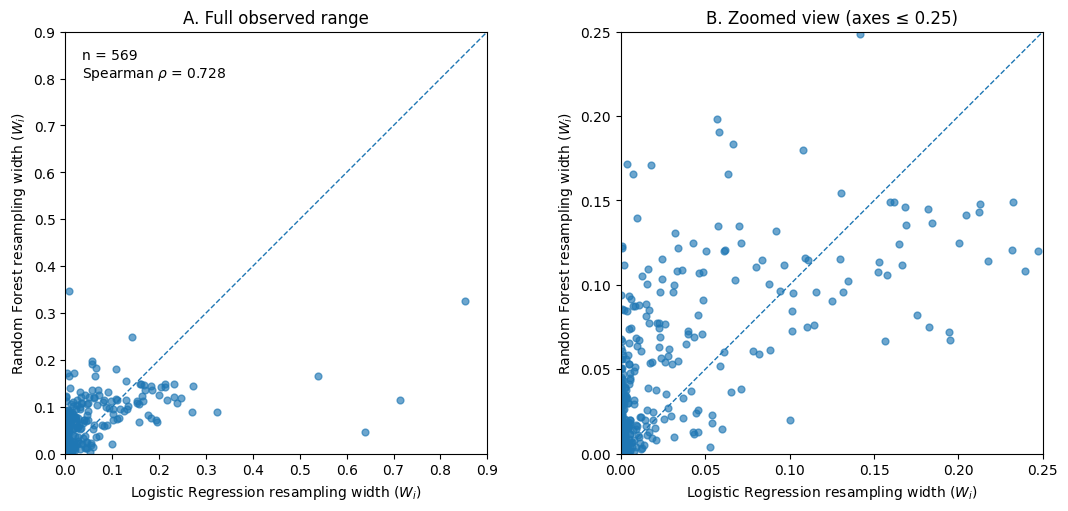

Saved: artifacts/figures/cross_procedure_resampling_width.png
Saved: artifacts/figures/cross_procedure_resampling_width.pdf


In [81]:
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Stage 5J — Figure S1: post-hoc exploratory cross-procedure figure
# ------------------------------------------------------------

plot_df = individual_comparison.copy()

x = plot_df["lr_resampling_width"]
y = plot_df["rf_resampling_width"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    constrained_layout=True,
)

# ------------------------------------------------------------
# Panel A — Full observed range
# ------------------------------------------------------------

full_limit = 0.90

axes[0].scatter(
    x,
    y,
    s=24,
    alpha=0.65,
)

axes[0].plot(
    [0, full_limit],
    [0, full_limit],
    linestyle="--",
    linewidth=1,
)

axes[0].set_xlim(0, full_limit)
axes[0].set_ylim(0, full_limit)

axes[0].set_aspect(
    "equal",
    adjustable="box",
)

axes[0].set_xlabel(
    "Logistic Regression resampling width ($W_i$)"
)

axes[0].set_ylabel(
    "Random Forest resampling width ($W_i$)"
)

axes[0].set_title(
    "A. Full observed range"
)

# Add sample size and rank correlation
axes[0].text(
    0.04,
    0.96,
    "n = 569\nSpearman $\\rho$ = 0.728",
    transform=axes[0].transAxes,
    va="top",
)

# ------------------------------------------------------------
# Panel B — Zoomed view
# ------------------------------------------------------------

zoom_limit = 0.25

axes[1].scatter(
    x,
    y,
    s=24,
    alpha=0.65,
)

axes[1].plot(
    [0, zoom_limit],
    [0, zoom_limit],
    linestyle="--",
    linewidth=1,
)

axes[1].set_xlim(0, zoom_limit)
axes[1].set_ylim(0, zoom_limit)

axes[1].set_aspect(
    "equal",
    adjustable="box",
)

axes[1].set_xlabel(
    "Logistic Regression resampling width ($W_i$)"
)

axes[1].set_ylabel(
    "Random Forest resampling width ($W_i$)"
)

axes[1].set_title(
    "B. Zoomed view (axes ≤ 0.25)"
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

figure_dir = Path(
    "artifacts/figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

png_path = (
    figure_dir
    / "cross_procedure_resampling_width.png"
)

pdf_path = (
    figure_dir
    / "cross_procedure_resampling_width.pdf"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

**Figure S1. Cross-procedure concordance of observation-level resampling instability.**  
This post-hoc exploratory comparison does not redefine the primary endpoints. Each point represents one WDBC observation; \(W_i=P_{90}(p_i)-P_{10}(p_i)\) is calculated from 50 out-of-sample predictions obtained under repeated model redevelopment. The dashed identity line represents equal resampling width under Logistic Regression and Random Forest. Panel A shows the complete observed range. Panel B shows the same observations with both axes restricted to 0–0.25 for visual inspection of the dense central region; observations outside this range are not displayed within the zoomed panel. Observation-level widths showed substantial rank concordance across procedures (Spearman \(\rho=0.728\)), although individual magnitudes could differ considerably.

In [82]:
from pathlib import Path

results_dir = Path("artifacts/results")
results_dir.mkdir(parents=True, exist_ok=True)

tie_audit_summary.to_csv(
    results_dir / "upper_tail_tie_audit_summary.csv",
    index=False,
)

robustness_primary.to_csv(
    results_dir / "upper_tail_robustness_summary.csv",
    index=False,
)

full50_member_stability.to_csv(
    results_dir / "upper_tail_membership_stability_summary.csv",
    index=False,
)

summary_40.to_csv(
    results_dir / "upper_tail_membership_m40_summary.csv",
    index=False,
)

print("✓ Stage 5I summary tables saved.")

✓ Stage 5I summary tables saved.


## Stage 5K: Aggregate performance stability

We next examine whether aggregate predictive performance remains stable across
the same 50 repeated model-development realizations used in the individual
prediction-stability analysis.

For each repetition:

- ROC-AUC summarizes discrimination. Following the prespecified analysis,
  fold-specific AUC values are combined using the number of positive-negative
  pairs in each test fold as weights.
- Brier score is calculated from the complete set of 569 out-of-sample
  predictions for that repetition.

The resulting distributions describe sensitivity of aggregate performance to
the redevelopment procedure conditional on the observed WDBC dataset and the
frozen resampling design. The 50 repetitions are not treated as independent
datasets or independent patient cohorts.

In [83]:
print("LR columns:")
print(lr_predictions.columns.tolist())

print("\nRF columns:")
print(rf_predictions.columns.tolist())

print("\nLR shape:", lr_predictions.shape)
print("RF shape:", rf_predictions.shape)

print("\nLR repeats:", lr_predictions["repeat"].nunique())
print("RF repeats:", rf_predictions["repeat"].nunique())

LR columns:
['model', 'repeat', 'fold', 'observation_id', 'row_index', 'y_true', 'predicted_probability']

RF columns:
['model', 'repeat', 'fold', 'observation_id', 'row_index', 'y_true', 'predicted_probability']

LR shape: (28450, 7)
RF shape: (28450, 7)

LR repeats: 50
RF repeats: 50


### Stage 5K.2: Aggregate metrics per redevelopment repetition

Aggregate metrics are recomputed directly from the saved out-of-sample
predictions.

For each repetition:

- Brier score is calculated from all 569 out-of-sample predictions.
- ROC-AUC is first calculated separately within each test fold and then
  combined using the number of positive-negative pairs in that fold,
  \(n_{+}n_{-}\), as the prespecified weight.

This reconstruction provides an independent consistency check of the
aggregate-performance results before visualization.

In [84]:
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np
import pandas as pd


def compute_aggregate_metrics(predictions):
    records = []

    for repeat, repeat_df in predictions.groupby(
        "repeat",
        sort=True,
    ):

        # ----------------------------------
        # Brier score:
        # all 569 OOS predictions
        # ----------------------------------

        assert len(repeat_df) == 569

        brier = brier_score_loss(
            repeat_df["y_true"],
            repeat_df["predicted_probability"],
        )

        # ----------------------------------
        # Weighted fold-specific ROC-AUC
        # ----------------------------------

        auc_values = []
        auc_weights = []

        for fold, fold_df in repeat_df.groupby(
            "fold",
            sort=True,
        ):

            n_positive = int(
                (fold_df["y_true"] == 1).sum()
            )

            n_negative = int(
                (fold_df["y_true"] == 0).sum()
            )

            assert n_positive > 0
            assert n_negative > 0

            fold_auc = roc_auc_score(
                fold_df["y_true"],
                fold_df["predicted_probability"],
            )

            pair_weight = (
                n_positive * n_negative
            )

            auc_values.append(
                fold_auc
            )

            auc_weights.append(
                pair_weight
            )

        weighted_auc = np.average(
            auc_values,
            weights=auc_weights,
        )

        records.append({
            "repeat": int(repeat),
            "weighted_auc": weighted_auc,
            "brier_score": brier,
        })

    result = pd.DataFrame(
        records
    ).sort_values(
        "repeat"
    ).reset_index(
        drop=True
    )

    return result


lr_aggregate = compute_aggregate_metrics(
    lr_predictions
)

rf_aggregate = compute_aggregate_metrics(
    rf_predictions
)


# Structural checks
assert len(lr_aggregate) == 50
assert len(rf_aggregate) == 50

np.testing.assert_array_equal(
    lr_aggregate["repeat"],
    rf_aggregate["repeat"],
)

print(
    "✓ Aggregate metrics reconstructed "
    "for all 50 paired repetitions."
)

display(
    lr_aggregate.head()
)

display(
    rf_aggregate.head()
)

✓ Aggregate metrics reconstructed for all 50 paired repetitions.


,repeat,weighted_auc,brier_score
0,0,0.994649,0.022546
1,1,0.995573,0.017812
2,2,0.994318,0.021696
3,3,0.995375,0.021245
4,4,0.994715,0.018907


,repeat,weighted_auc,brier_score
0,0,0.990618,0.031651
1,1,0.990057,0.031057
2,2,0.990883,0.031045
3,3,0.989693,0.031594
4,4,0.990883,0.030557


In [85]:
def summarize_aggregate_metrics(
    df,
    procedure,
):
    return {
        "procedure": procedure,

        "auc_mean":
            df["weighted_auc"].mean(),

        "auc_sd":
            df["weighted_auc"].std(
                ddof=1
            ),

        "auc_min":
            df["weighted_auc"].min(),

        "auc_median":
            df["weighted_auc"].median(),

        "auc_max":
            df["weighted_auc"].max(),

        "brier_mean":
            df["brier_score"].mean(),

        "brier_sd":
            df["brier_score"].std(
                ddof=1
            ),

        "brier_min":
            df["brier_score"].min(),

        "brier_median":
            df["brier_score"].median(),

        "brier_max":
            df["brier_score"].max(),
    }


aggregate_stability_summary = pd.DataFrame([
    summarize_aggregate_metrics(
        lr_aggregate,
        "Logistic Regression",
    ),
    summarize_aggregate_metrics(
        rf_aggregate,
        "Random Forest",
    ),
])

display(
    aggregate_stability_summary
)

,procedure,auc_mean,auc_sd,auc_min,auc_median,auc_max,brier_mean,brier_sd,brier_min,brier_median,brier_max
0,Logistic Regression,0.994556,0.001299,0.990156,0.994715,0.996564,0.020547,0.001677,0.017014,0.020540,0.024350
1,Random Forest,0.990640,0.000924,0.987744,0.990701,0.992303,0.031696,0.001008,0.029944,0.031524,0.034994


In [86]:
results_dir = Path("artifacts/results")
results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

aggregate_stability_summary.to_csv(
    results_dir / "aggregate_performance_stability_summary.csv",
    index=False,
)

lr_aggregate.to_csv(
    results_dir / "logistic_regression_aggregate_metrics.csv",
    index=False,
)

rf_aggregate.to_csv(
    results_dir / "random_forest_aggregate_metrics.csv",
    index=False,
)

print("✓ Aggregate-performance tables saved.")

✓ Aggregate-performance tables saved.


### Figure 2: Aggregate performance stability across redevelopment repetitions

Each point represents one complete repeated 5-fold cross-validation
realization.

Logistic Regression and Random Forest results are paired because both
procedures were evaluated using the same frozen resampling assignments.
Connecting lines therefore show the within-repetition difference between
procedures, while the vertical spread within each procedure shows sensitivity
of aggregate performance to redevelopment.

Panel A shows pair-weighted ROC-AUC. Panel B shows Brier score.

The distributions are descriptive summaries of the 50 redevelopment
realizations and are not interpreted as independent-sample uncertainty
distributions.

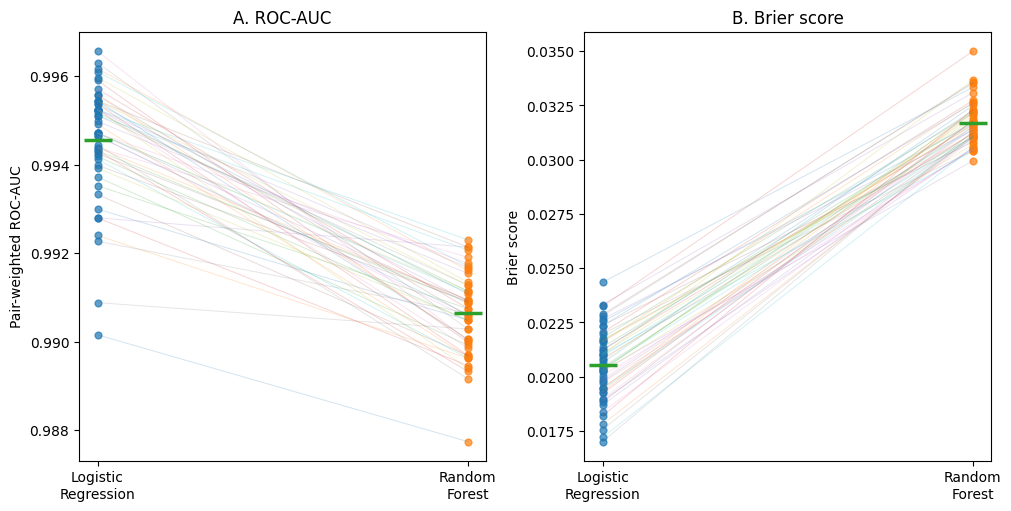

Saved: artifacts/figures/aggregate_performance_stability.png
Saved: artifacts/figures/aggregate_performance_stability.pdf


In [87]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


# Explicitly align the same repetitions
aggregate_plot = (
    lr_aggregate
    .rename(
        columns={
            "weighted_auc": "lr_auc",
            "brier_score": "lr_brier",
        }
    )
    .merge(
        rf_aggregate.rename(
            columns={
                "weighted_auc": "rf_auc",
                "brier_score": "rf_brier",
            }
        ),
        on="repeat",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("repeat")
    .reset_index(drop=True)
)

assert len(aggregate_plot) == 50
assert aggregate_plot["repeat"].tolist() == list(range(50))


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    constrained_layout=True,
)

x_lr = 0
x_rf = 1


# ==========================================================
# Panel A — ROC-AUC
# ==========================================================

ax = axes[0]

for _, row in aggregate_plot.iterrows():

    ax.plot(
        [x_lr, x_rf],
        [row["lr_auc"], row["rf_auc"]],
        linewidth=0.7,
        alpha=0.20,
    )

ax.scatter(
    np.full(len(aggregate_plot), x_lr),
    aggregate_plot["lr_auc"],
    s=24,
    alpha=0.70,
)

ax.scatter(
    np.full(len(aggregate_plot), x_rf),
    aggregate_plot["rf_auc"],
    s=24,
    alpha=0.70,
)

ax.scatter(
    [x_lr, x_rf],
    [
        aggregate_plot["lr_auc"].mean(),
        aggregate_plot["rf_auc"].mean(),
    ],
    marker="_",
    s=400,
    linewidth=2.5,
    zorder=5,
)

ax.set_xticks(
    [x_lr, x_rf],
    [
        "Logistic\nRegression",
        "Random\nForest",
    ],
)

ax.set_ylabel(
    "Pair-weighted ROC-AUC"
)

ax.set_title(
    "A. ROC-AUC"
)


# ==========================================================
# Panel B — Brier score
# ==========================================================

ax = axes[1]

for _, row in aggregate_plot.iterrows():

    ax.plot(
        [x_lr, x_rf],
        [row["lr_brier"], row["rf_brier"]],
        linewidth=0.7,
        alpha=0.20,
    )

ax.scatter(
    np.full(len(aggregate_plot), x_lr),
    aggregate_plot["lr_brier"],
    s=24,
    alpha=0.70,
)

ax.scatter(
    np.full(len(aggregate_plot), x_rf),
    aggregate_plot["rf_brier"],
    s=24,
    alpha=0.70,
)

ax.scatter(
    [x_lr, x_rf],
    [
        aggregate_plot["lr_brier"].mean(),
        aggregate_plot["rf_brier"].mean(),
    ],
    marker="_",
    s=400,
    linewidth=2.5,
    zorder=5,
)

ax.set_xticks(
    [x_lr, x_rf],
    [
        "Logistic\nRegression",
        "Random\nForest",
    ],
)

ax.set_ylabel(
    "Brier score"
)

ax.set_title(
    "B. Brier score"
)


# ==========================================================
# Save
# ==========================================================

figure_dir = Path(
    "artifacts/figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

png_path = (
    figure_dir
    / "aggregate_performance_stability.png"
)

pdf_path = (
    figure_dir
    / "aggregate_performance_stability.pdf"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

**Figure 2. Aggregate performance stability across redevelopment repetitions.** Each point represents one complete repeated stratified 5-fold cross-validation realization. Panel A shows positive-negative-pair-weighted fold ROC-AUC; Panel B shows Brier score across the complete out-of-sample prediction vector. Connecting lines pair Logistic Regression and Random Forest within the same frozen repetition, and horizontal markers show procedure means. The spread describes sensitivity to redevelopment across 50 repetitions, which are not independent patient cohorts or population uncertainty intervals.


## Stage 5L: Individual prediction stability across the probability scale

For each WDBC observation, repeated model redevelopment yields 50 genuine
out-of-sample predicted probabilities.

Each observation is summarized by:

- its median out-of-sample predicted probability of malignancy; and
- its individual resampling width,

\[
W_i = P_{90}(p_i) - P_{10}(p_i).
\]

The resulting plots show where observation-level resampling sensitivity is
concentrated along the predicted-probability scale.

Logistic Regression and Random Forest are displayed using identical axis
limits to permit direct visual comparison.

The vertical line at probability 0.5 is included only as a geometric
reference. It is not presented as a clinically validated decision threshold.

In [88]:
from pathlib import Path
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Structural checks
# ----------------------------------------------------------

required_columns = {
    "observation_id",
    "y_true",
    "median_probability",
    "resampling_width",
}

assert required_columns.issubset(
    lr_individual.columns
)

assert required_columns.issubset(
    rf_individual.columns
)

assert len(lr_individual) == 569
assert len(rf_individual) == 569

assert lr_individual["median_probability"].between(0, 1).all()
assert rf_individual["median_probability"].between(0, 1).all()

assert (lr_individual["resampling_width"] >= 0).all()
assert (rf_individual["resampling_width"] >= 0).all()

print(
    "✓ Individual stability tables validated for Figure 3."
)

✓ Individual stability tables validated for Figure 3.


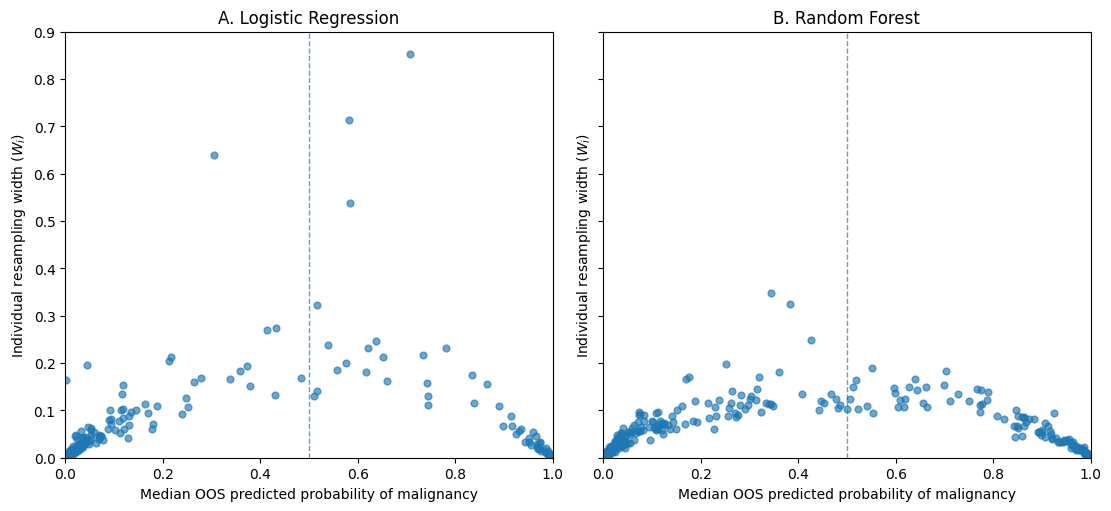

Saved: artifacts/figures/individual_prediction_stability.png
Saved: artifacts/figures/individual_prediction_stability.pdf


In [89]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

y_limit = 0.90


# ==========================================================
# Panel A — Logistic Regression
# ==========================================================

ax = axes[0]

ax.scatter(
    lr_individual["median_probability"],
    lr_individual["resampling_width"],
    s=24,
    alpha=0.65,
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xlim(0, 1)
ax.set_ylim(0, y_limit)

ax.set_xlabel(
    "Median OOS predicted probability of malignancy"
)

ax.set_ylabel(
    "Individual resampling width ($W_i$)"
)

ax.set_title(
    "A. Logistic Regression"
)


# ==========================================================
# Panel B — Random Forest
# ==========================================================

ax = axes[1]

ax.scatter(
    rf_individual["median_probability"],
    rf_individual["resampling_width"],
    s=24,
    alpha=0.65,
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xlim(0, 1)
ax.set_ylim(0, y_limit)

ax.set_xlabel(
    "Median OOS predicted probability of malignancy"
)

ax.set_ylabel(
    "Individual resampling width ($W_i$)"
)

ax.set_title(
    "B. Random Forest"
)


# ==========================================================
# Save
# ==========================================================

figure_dir = Path(
    "artifacts/figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

png_path = (
    figure_dir
    / "individual_prediction_stability.png"
)

pdf_path = (
    figure_dir
    / "individual_prediction_stability.pdf"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

**Figure 3. Observation-level prediction stability across the predicted-probability scale.** Each point represents one WDBC observation summarized across 50 repeated out-of-sample predictions. The x-axis shows the median predicted probability of malignancy and the y-axis shows the individual resampling width, \(W_i=P_{90}(p_i)-P_{10}(p_i)\), which quantifies the central 80% spread of predictions assigned to that observation under repeated redevelopment. Panel A shows Logistic Regression and Panel B shows Random Forest using identical axis limits. The dashed vertical line at 0.5 is included only as a geometric reference and is not interpreted as a clinically validated decision threshold. Larger \(W_i\) values indicate greater sensitivity of the assigned probability to changes in the training sample under the specified resampling procedure.

## Stage 5M: Main results summary

The primary results are consolidated into a compact table summarizing both
aggregate predictive performance and observation-level prediction stability.

For each learning procedure, the table reports:

- mean ROC-AUC across the 50 redevelopment repetitions;
- standard deviation of ROC-AUC across repetitions;
- mean Brier score across repetitions;
- standard deviation of Brier score across repetitions;
- median individual resampling width;
- 90th percentile of individual resampling width.

Aggregate-metric variability and individual probability-width variability are
reported side by side but are not interpreted as quantities on a common
numerical scale.

In [90]:
main_results_table = pd.DataFrame({
    "procedure": [
        "Prevalence-only control",
        "Logistic Regression",
        "Random Forest",
    ],

    "mean_auc": [
        baseline_auc["auc"].mean(),
        lr_aggregate["weighted_auc"].mean(),
        rf_aggregate["weighted_auc"].mean(),
    ],

    "sd_auc": [
        baseline_auc["auc"].std(ddof=1),
        lr_aggregate["weighted_auc"].std(ddof=1),
        rf_aggregate["weighted_auc"].std(ddof=1),
    ],

    "mean_brier": [
        baseline_brier["brier"].mean(),
        lr_aggregate["brier_score"].mean(),
        rf_aggregate["brier_score"].mean(),
    ],

    "sd_brier": [
        baseline_brier["brier"].std(ddof=1),
        lr_aggregate["brier_score"].std(ddof=1),
        rf_aggregate["brier_score"].std(ddof=1),
    ],

    "median_W": [
        baseline_individual["resampling_width"].median(),
        lr_individual["resampling_width"].median(),
        rf_individual["resampling_width"].median(),
    ],

    "P90_W": [
        np.quantile(
            baseline_individual["resampling_width"],
            0.90,
            method="linear",
        ),
        np.quantile(
            lr_individual["resampling_width"],
            0.90,
            method="linear",
        ),
        np.quantile(
            rf_individual["resampling_width"],
            0.90,
            method="linear",
        ),
    ],
})

display(main_results_table)

main_results_table.to_csv(
    results_dir / "main_results_table.csv",
    index=False,
)

,procedure,mean_auc,sd_auc,mean_brier,sd_brier,median_W,P90_W
0,Prevalence-only control,0.500000,0.000000,0.233774,2.803737e-17,0.002198,0.002198
1,Logistic Regression,0.994556,0.001299,0.020547,1.676795e-03,0.001004,0.072620
2,Random Forest,0.990640,0.000924,0.031696,1.007779e-03,0.010450,0.107858


## Stage 5N: Sensitivity to the sample-quantile convention

The primary individual resampling width was prespecified as:

\[
W_i = Q_{0.90}(p_i) - Q_{0.10}(p_i),
\]

using NumPy's `method="linear"` quantile convention.

Because each observation has only 50 repeated out-of-sample predictions,
different finite-sample quantile conventions can produce slightly different
values of \(W_i\), particularly for observations near the top-decile
instability boundary.

As a post-hoc robustness analysis, resampling widths are recomputed using
several alternative sample-quantile conventions.

The purpose is not to select the convention producing the most favorable
result. `linear` remains the primary prespecified definition.

We evaluate whether alternative conventions materially change:

1. the distribution of individual resampling widths;
2. cross-procedure rank concordance;
3. membership of each procedure's top-57 instability set; and
4. LR–RF upper-tail overlap.

Boundary ties at ranks 57 and 58 are recorded explicitly.

In [91]:
from scipy.stats import spearmanr

QUANTILE_METHODS = [
    "linear",
    "nearest",
    "lower",
    "higher",
    "midpoint",
]

quantile_sensitivity_records = []
quantile_top_sets = {}


def compute_widths_method(
    prediction_matrix,
    method,
):
    q10 = np.quantile(
        prediction_matrix,
        0.10,
        axis=1,
        method=method,
    )

    q90 = np.quantile(
        prediction_matrix,
        0.90,
        axis=1,
        method=method,
    )

    return q90 - q10


def boundary_audit_simple(
    widths,
    n_top=57,
    atol=1e-12,
):
    ordered = np.sort(widths)[::-1]

    rank_57 = ordered[n_top - 1]
    rank_58 = ordered[n_top]

    gap = rank_57 - rank_58

    exact_tie = bool(
        rank_57 == rank_58
    )

    near_tie = bool(
        np.isclose(
            rank_57,
            rank_58,
            rtol=0.0,
            atol=atol,
        )
    )

    return (
        rank_57,
        rank_58,
        gap,
        exact_tie,
        near_tie,
    )


for method in QUANTILE_METHODS:

    lr_width = compute_widths_method(
        lr_array,
        method,
    )

    rf_width = compute_widths_method(
        rf_array,
        method,
    )

    # Cross-procedure rank concordance
    rho_method, _ = spearmanr(
        lr_width,
        rf_width,
    )

    # Audit boundaries before interpreting top-57 sets
    (
        lr_rank57,
        lr_rank58,
        lr_gap,
        lr_exact_tie,
        lr_near_tie,
    ) = boundary_audit_simple(
        lr_width,
        n_top=n_top,
    )

    (
        rf_rank57,
        rf_rank58,
        rf_gap,
        rf_exact_tie,
        rf_near_tie,
    ) = boundary_audit_simple(
        rf_width,
        n_top=n_top,
    )

    # Deterministic top-57 sets
    lr_top = top_n_mask(
        lr_width,
        observation_ids,
        n_top,
    )

    rf_top = top_n_mask(
        rf_width,
        observation_ids,
        n_top,
    )

    shared = int(
        np.sum(
            lr_top & rf_top
        )
    )

    union = int(
        np.sum(
            lr_top | rf_top
        )
    )

    jaccard = (
        shared / union
    )

    quantile_top_sets[
        method
    ] = {
        "lr": lr_top,
        "rf": rf_top,
    }

    quantile_sensitivity_records.append({
        "method": method,

        "lr_median_W":
            np.median(lr_width),

        "lr_P90_W":
            np.quantile(
                lr_width,
                0.90,
                method="linear",
            ),

        "rf_median_W":
            np.median(rf_width),

        "rf_P90_W":
            np.quantile(
                rf_width,
                0.90,
                method="linear",
            ),

        "spearman_rho":
            rho_method,

        "shared_top57":
            shared,

        "shared_proportion":
            shared / n_top,

        "jaccard":
            jaccard,

        "lr_cutoff_gap":
            lr_gap,

        "rf_cutoff_gap":
            rf_gap,

        "lr_exact_boundary_tie":
            lr_exact_tie,

        "rf_exact_boundary_tie":
            rf_exact_tie,

        "lr_near_boundary_tie":
            lr_near_tie,

        "rf_near_boundary_tie":
            rf_near_tie,
    })


quantile_sensitivity = pd.DataFrame(
    quantile_sensitivity_records
)

display(
    quantile_sensitivity
)

,method,lr_median_W,lr_P90_W,rf_median_W,rf_P90_W,spearman_rho,shared_top57,shared_proportion,jaccard,lr_cutoff_gap,rf_cutoff_gap,lr_exact_boundary_tie,rf_exact_boundary_tie,lr_near_boundary_tie,rf_near_boundary_tie
0,linear,0.001004,0.072620,0.010450,0.107858,0.727522,32,0.561404,0.390244,0.006825,0.000288,False,False,False,False
1,nearest,0.000990,0.071500,0.010375,0.107050,0.727851,32,0.561404,0.390244,0.006093,0.000250,False,False,False,False
2,lower,0.001020,0.077327,0.010875,0.110275,0.726010,32,0.561404,0.390244,0.008027,0.000125,False,False,False,False
3,higher,0.001039,0.077366,0.011125,0.112125,0.730308,32,0.561404,0.390244,0.006682,0.000625,False,False,False,False
4,midpoint,0.001035,0.077347,0.010750,0.110787,0.728474,32,0.561404,0.390244,0.007354,0.002063,False,False,False,False


In [92]:
linear_lr_top = (
    quantile_top_sets["linear"]["lr"]
)

linear_rf_top = (
    quantile_top_sets["linear"]["rf"]
)

method_membership_records = []

for method in QUANTILE_METHODS:

    lr_top = (
        quantile_top_sets[method]["lr"]
    )

    rf_top = (
        quantile_top_sets[method]["rf"]
    )

    lr_shared_with_linear = int(
        np.sum(
            lr_top & linear_lr_top
        )
    )

    rf_shared_with_linear = int(
        np.sum(
            rf_top & linear_rf_top
        )
    )

    method_membership_records.append({
        "method": method,

        "lr_shared_with_linear":
            lr_shared_with_linear,

        "lr_overlap_with_linear":
            lr_shared_with_linear / n_top,

        "rf_shared_with_linear":
            rf_shared_with_linear,

        "rf_overlap_with_linear":
            rf_shared_with_linear / n_top,
    })


quantile_membership_sensitivity = pd.DataFrame(
    method_membership_records
)

display(
    quantile_membership_sensitivity
)

,method,lr_shared_with_linear,lr_overlap_with_linear,rf_shared_with_linear,rf_overlap_with_linear
0,linear,57,1.0,57,1.000000
1,nearest,57,1.0,55,0.964912
2,lower,57,1.0,55,0.964912
3,higher,57,1.0,56,0.982456
4,midpoint,57,1.0,56,0.982456


## Reproducibility checkpoint: save canonical analysis artifacts

The complete out-of-sample predictions and core deterministic summaries are
saved explicitly so that the reported results can be reconstructed without
refitting the models.

In [93]:
from pathlib import Path

prediction_dir = Path("artifacts/predictions")
diagnostic_dir = Path("artifacts/diagnostics")
results_dir = Path("artifacts/results")

for directory in [
    prediction_dir,
    diagnostic_dir,
    results_dir,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ----------------------------------------------------------
# Complete OOS prediction tables
# ----------------------------------------------------------

prevalence_predictions.to_csv(
    prediction_dir / "prevalence_oos_predictions.csv",
    index=False,
)

lr_predictions.to_csv(
    prediction_dir / "logistic_regression_oos_predictions.csv",
    index=False,
)

# ----------------------------------------------------------
# Logistic Regression deterministic fit diagnostics
# ----------------------------------------------------------

lr_fit_diagnostics.to_csv(
    diagnostic_dir / "logistic_regression_fit_diagnostics.csv",
    index=False,
)


# ----------------------------------------------------------
# Observation-level summaries
# ----------------------------------------------------------

baseline_individual.reset_index().to_csv(
    results_dir / "prevalence_individual_stability.csv",
    index=False,
)

lr_individual.to_csv(
    results_dir / "logistic_regression_individual_stability.csv",
    index=False,
)

rf_individual.to_csv(
    results_dir / "random_forest_individual_stability.csv",
    index=False,
)

individual_comparison.to_csv(
    results_dir / "cross_procedure_individual_comparison.csv",
    index=False,
)

print("✓ Canonical prediction and stability artifacts saved.")

✓ Canonical prediction and stability artifacts saved.


### Stage 5N: Robustness conclusion

The primary resampling-width definition used NumPy's `method="linear"` quantile
convention, as prespecified.

As a post-hoc robustness analysis, individual resampling widths were recomputed
using `nearest`, `lower`, `higher`, and `midpoint` quantile conventions.

The main cross-procedure findings were highly insensitive to this numerical
choice:

- the number of shared top-57 observations remained 32 under every method;
- the shared proportion remained 56.1%;
- the Jaccard index remained 0.390 under every method;
- cross-procedure Spearman rank correlation remained approximately 0.73;
- no exact or numerically indistinguishable rank-57/rank-58 boundary ties were observed at the prespecified \(10^-12\) tolerance.

The Logistic Regression top-57 set was identical under all five conventions.
For Random Forest, 55–56 of the 57 observations selected using alternative
methods were also selected using the primary `linear` convention.

Thus, although alternative quantile definitions produced small changes in the
numerical values of individual resampling widths, they did not materially alter
the upper-tail concordance result.

In [94]:
quantile_sensitivity.to_csv(
    results_dir / "quantile_method_sensitivity.csv",
    index=False,
)

quantile_membership_sensitivity.to_csv(
    results_dir / "quantile_method_membership_sensitivity.csv",
    index=False,
)

print("✓ Quantile-method robustness tables saved.")

✓ Quantile-method robustness tables saved.
